# 📊 VEO Tactics Notebook
**TFG Análisis Táctico — Métricas Avanzadas**

> **Prerequisito**: ejecuta primero `veo_tracking_banyoles.ipynb` y exporta el CSV (celda 11). Este notebook lee ese CSV y calcula todas las métricas tácticas.

| Celda | Métrica |
|-------|---------|
| 1 | Carga datos + resumen |
| 1b | **Consolidación de IDs** — fusiona tracks fragmentados |
| 2 | Campo matplotlib (función base) |
| 3 | **Compacidad** — convex hull, centroide, línea defensiva |
| 4 | **Velocidad y sprints** — distribución, mapa de velocidad |
| 5 | **Zonas de control** — diagrama de Voronoi interactivo |
| 6 | **Pressing** — pressing index, posesión estimada |
| 7 | **Formación** — posiciones medias, líneas tácticas |
| 8 | **Dominancia** — barras de presión y control territorial |
| 9 | **Día vs Noche** — comparativa única de este dataset |
| 10 | **Estadísticas avanzadas** — esfuerzo, cobertura, proximidad |
| 11 | **Dashboard** — figura resumen de 12 paneles |


## 1 · Carga de datos
Lee el CSV de trayectorias generado por el notebook de tracking.
Cambia `CSV_PATH` y los parámetros del campo si es necesario.

In [13]:
# ═══════════════════════════════════════════════════════════
#  CARGA DEL CSV DE TRAYECTORIAS
#  Generado por veo_tracking_banyoles.ipynb (celda 11)
# ═══════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
from matplotlib.patches import Rectangle, Circle, Arc, FancyArrowPatch
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
from scipy.spatial import ConvexHull, Voronoi, voronoi_plot_2d
from collections import defaultdict
import warnings, os
warnings.filterwarnings('ignore')

# ── Parametros — edita aqui ────────────────────────────────
CSV_PATH    = "tracking_veo_panoramico_banyoles_f18000-18900.csv"
L_M         = 98.0    # longitud del campo (m)
A_M         = 61.0    # anchura del campo (m)
FPS         = 30.0    # fps del video original
# Velocidad — todo se muestra en km/h en las graficas
# 1 m/s = 3.6 km/h
MS_TO_KMH   = 3.6
SPRINT_KMH  = 25.0    # umbral sprint en km/h  (~7 m/s)
SPRINT_MS   = SPRINT_KMH / MS_TO_KMH   # equivalente en m/s (usado internamente)
JOG_KMH     = 11.0    # trote (11-18 km/h)
RUN_KMH     = 18.0    # carrera (18-25 km/h)
PRESS_DIST  = 5.0     # distancia (m) para considerar presion al portador
BALL_DIST   = 2.0     # distancia (m) jugador-balon para posesion

DARK_BG     = '#0d1117'
GRASS_DARK  = '#1a472a'
GRASS_LIGHT = '#215732'
LINE_COLOR  = 'white'

COLOR_MAP = {
    'player_home': '#DC143C',
    'player_away': '#1E90FF',
    'gk_home':     '#FF00FF',
    'gk_away':     '#00CED1',
    'referee':     '#FFD700',
    'unknown':     '#888888',
    'ball':        '#FF6B35',
}
CLASSES_ORDER = ['player_home', 'player_away', 'gk_home', 'gk_away', 'referee']
TEAM_HOME = ['player_home', 'gk_home']
TEAM_AWAY = ['player_away', 'gk_away']

# ── Carga ──────────────────────────────────────────────────
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(
        f"No se encontro {CSV_PATH}.\n"
        "Ejecuta primero veo_tracking_banyoles.ipynb (celda 11 - Exportacion)."
    )

df = pd.read_csv(CSV_PATH)
# Asegurarse de que la columna time_s existe
if 'time_s' not in df.columns and 'frame' in df.columns:
    df['time_s'] = (df['frame'] - df['frame'].min()) / FPS

# CSV opcional del balon
CSV_BALL = CSV_PATH.replace('.csv', '_ball.csv')
df_ball = pd.read_csv(CSV_BALL) if os.path.exists(CSV_BALL) else pd.DataFrame()
if len(df_ball) and 'time_s' not in df_ball.columns:
    df_ball['time_s'] = (df_ball['frame'] - df_ball['frame'].min()) / FPS

# ── Resumen ─────────────────────────────────────────────────
t_total = df['time_s'].max() - df['time_s'].min() if len(df) else 0
print(f"Datos cargados: {len(df)} registros  |  "
      f"{df['gid'].nunique()} IDs  |  {t_total:.1f} s")
print(f"Columnas: {list(df.columns)}")
if len(df_ball):
    print(f"Balon: {len(df_ball)} registros")
else:
    print("Balon: sin datos (ejecuta con MODEL_BALL configurado)")

# Filtrar 'unknown' para metricas (mantener en df original)
df_known = df[df['cls'].isin(CLASSES_ORDER)].copy()
print(f"\nSin 'unknown': {len(df_known)} registros "
      f"({100*len(df_known)/len(df):.1f}% del total)")


Datos cargados: 14186 registros  |  50 IDs  |  29.9 s
Columnas: ['frame', 'gid', 'cls', 'x_m', 'y_m', 'conf', 'speed_ms', 'cam', 'time_s', 'zone']
Balon: sin datos (ejecuta con MODEL_BALL configurado)

Sin 'unknown': 14180 registros (100.0% del total)


## 1b · Consolidación de IDs fragmentados
El tracker puede crear IDs nuevos cuando pierde un jugador por oclusión o fallo del modelo. Esta celda **fusiona automáticamente** los tracks fragmentados usando tres criterios:

- **Continuidad temporal**: gap entre tracks ≤ `MAX_GAP_FRAMES` (3 s)
- **Continuidad espacial**: distancia entre el fin de A y el inicio de B ≤ `MAX_GAP_DIST_M`
- **Coherencia de clase**: mismo equipo votado

El resultado reemplaza `df` y `df_known` con los IDs limpios para todas las celdas siguientes. También guarda el diagnóstico visual de la fragmentación.


═══════════════════════════════════════════════════════
  DIAGNOSTICO DE IDS
  ──────────────────────────────────────────────────
  IDs totales           : 50
  IDs ≥ 5 frames (reales) : 47
  IDs ghost (<5 frames)   : 3
  Duracion media (frames): 283.7
  Duracion mediana       : 90
  Track mas largo        : 893 frames (ID #2)


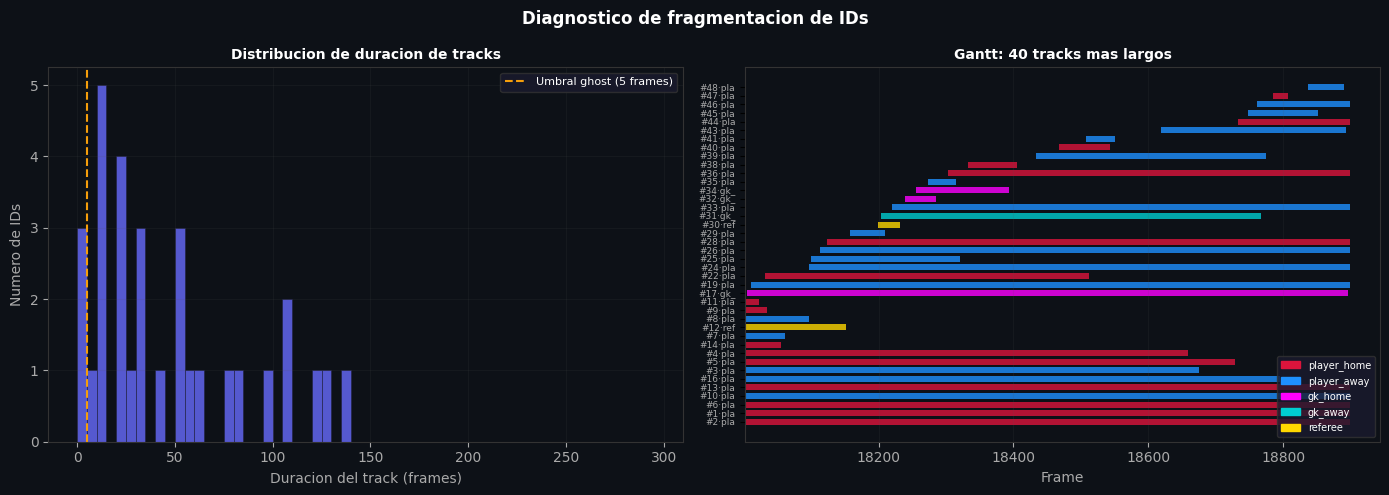

Figura guardada: diagnostico_ids.png

Consolidando IDs...
  Iter 1: fusionados 10 pares → IDs activos: 40
  Iter 2: fusionados 1 pares → IDs activos: 39

═══════════════════════════════════════════════════════
  RESULTADO DE CONSOLIDACION
  ──────────────────────────────────────────────────
  IDs antes : 50
  IDs despues: 39  (reduccion del 22%)
  Fusiones realizadas: 11

  Detalle de fusiones:
   ID_A ←  ID_B     Gap    Dist  Clase
  ────────────────────────────────────────
  #   3 ← #  46     86f    0.5m  player_away
  #   5 ← #  47     57f    0.8m  player_home
  #   7 ← #  24     36f    2.5m  player_away
  #   8 ← #  26     16f    1.4m  player_away
  #   9 ← #  28     90f    3.1m  player_home
  #  12 ← #  30     47f    4.9m  referee
  #  14 ← #  23      5f    3.6m  player_home
  #  29 ← #  33     11f    3.9m  player_away
  #  38 ← #  40     62f    1.2m  player_home
  #  41 ← #  43     69f    0.4m  player_away
  #  18 ← #  25     49f    6.7m  player_away

CSV consolidado guardado: tr

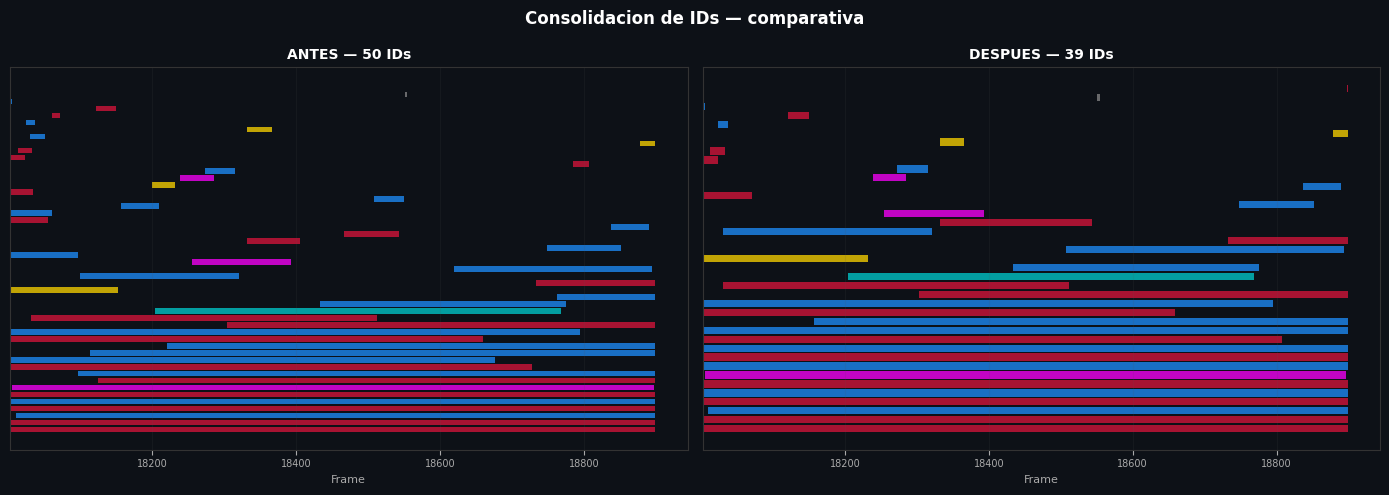

Figura guardada: consolidacion_ids.png


In [14]:
# ═══════════════════════════════════════════════════════════
#  POST-PROCESO: CONSOLIDACION DE IDs FRAGMENTADOS
#
#  Problema: el tracker puede asignar IDs nuevos cuando pierde
#  temporalmente un jugador (oclusion, fallo del modelo, jitter
#  de homografia). Resultado: 90 IDs para 22 jugadores reales.
#
#  Esta celda lee el CSV ya exportado y fusiona IDs que
#  claramente pertenecen al mismo jugador usando tres criterios:
#
#    1. Continuidad temporal: el gap entre el ultimo frame del
#       track A y el primer frame del track B es pequeño.
#    2. Continuidad espacial: la posicion final de A y la inicial
#       de B estan cerca (teniendo en cuenta la velocidad).
#    3. Coherencia de clase: ambos tienen la misma clase votada.
#
#  El resultado se guarda como un CSV nuevo con IDs limpios.
#  IMPORTANTE: ejecuta esta celda ANTES de las demas de tacticas.
# ═══════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings; warnings.filterwarnings('ignore')

# ── Parametros de consolidacion ───────────────────────────
# Gap maximo (frames) entre el fin de un track y el inicio del siguiente
# para que se consideren "el mismo jugador"
MAX_GAP_FRAMES = 90          # 3s a 30fps — amplio para cubrir oclusiones largas

# Distancia maxima (m) entre la ultima posicion de A y la primera de B
# Ampliado para cubrir el movimiento durante el gap:
# un jugador puede moverse ~6 m/s → en 3s = 18m. Pero queremos conservadores.
MAX_GAP_DIST_M = 12.0        # metros

# Minimo de frames para que un track sea considerado "real"
# Los ghost tracks (espectadores, detecciones falsas) suelen durar <5 frames
MIN_FRAMES_REAL = 5

# Activar debug: muestra los merges realizados
CONSOLIDATE_DEBUG = True

# ── Carga del CSV ──────────────────────────────────────────
# (ya cargado por 01_load_data.py — aqui lo recargamos por si
#  esta celda se ejecuta sola)
if 'df' not in dir() or len(df) == 0:
    import os
    CSV_PATH = "tracking_veo_panoramico_banyoles_f18000-18900.csv"
    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(f"No se encontro {CSV_PATH}")
    df = pd.read_csv(CSV_PATH)
    if 'time_s' not in df.columns:
        df['time_s'] = (df['frame'] - df['frame'].min()) / FPS
    print(f"CSV recargado: {len(df)} filas, {df['gid'].nunique()} IDs")


# ── Analisis previo: duracion de cada track ───────────────
def _track_summary(df_in):
    rows = []
    for gid, grp in df_in.groupby('gid'):
        grp_s = grp.sort_values('frame')
        cls_v = grp_s['cls'].mode()[0]
        rows.append({
            'gid':        gid,
            'cls':        cls_v,
            'n_frames':   len(grp_s),
            'f_start':    int(grp_s['frame'].min()),
            'f_end':      int(grp_s['frame'].max()),
            'x_start':    float(grp_s.iloc[0]['x_m']),
            'y_start':    float(grp_s.iloc[0]['y_m']),
            'x_end':      float(grp_s.iloc[-1]['x_m']),
            'y_end':      float(grp_s.iloc[-1]['y_m']),
        })
    return pd.DataFrame(rows).sort_values('f_start').reset_index(drop=True)


df_tracks = _track_summary(df)
n_ids_orig = df['gid'].nunique()

print(f"\n{'═'*55}")
print(f"  DIAGNOSTICO DE IDS")
print(f"  {'─'*50}")
print(f"  IDs totales           : {n_ids_orig}")
print(f"  IDs ≥ {MIN_FRAMES_REAL} frames (reales) : "
      f"{(df_tracks['n_frames'] >= MIN_FRAMES_REAL).sum()}")
print(f"  IDs ghost (<{MIN_FRAMES_REAL} frames)   : "
      f"{(df_tracks['n_frames'] < MIN_FRAMES_REAL).sum()}")
print(f"  Duracion media (frames): {df_tracks['n_frames'].mean():.1f}")
print(f"  Duracion mediana       : {df_tracks['n_frames'].median():.0f}")
print(f"  Track mas largo        : {df_tracks['n_frames'].max()} frames "
      f"(ID #{df_tracks.loc[df_tracks['n_frames'].idxmax(),'gid']})")


# ── Figura 1: histograma de duracion de tracks ────────────
fig_diag, axes_d = plt.subplots(1, 2, figsize=(14, 5))
fig_diag.patch.set_facecolor(DARK_BG)

ax_hist = axes_d[0]
ax_hist.set_facecolor(DARK_BG)
for sp in ax_hist.spines.values(): sp.set_color('#333')
bins = np.arange(0, min(df_tracks['n_frames'].max() + 10, 300), 5)
col_real  = np.where(
    df_tracks['n_frames'] >= MIN_FRAMES_REAL, '#22c55e', '#ef4444')
ax_hist.hist(df_tracks['n_frames'], bins=bins,
             color='#6366f1', edgecolor='#1a1a2e', lw=0.4, alpha=0.85)
ax_hist.axvline(MIN_FRAMES_REAL, color='#f59e0b', lw=1.5, ls='--',
                label=f'Umbral ghost ({MIN_FRAMES_REAL} frames)')
ax_hist.set_xlabel('Duracion del track (frames)', color='#aaa')
ax_hist.set_ylabel('Numero de IDs', color='#aaa')
ax_hist.tick_params(colors='#aaa')
ax_hist.grid(alpha=0.12, color='#555')
ax_hist.legend(fontsize=8, facecolor='#1a1a2e', labelcolor='white',
               edgecolor='#333', framealpha=0.8)
ax_hist.set_title('Distribucion de duracion de tracks', color='white',
                  fontsize=10, fontweight='bold')

# Diagrama de Gantt: tracks por ID (top 40 mas largos)
ax_gtt = axes_d[1]
ax_gtt.set_facecolor(DARK_BG)
for sp in ax_gtt.spines.values(): sp.set_color('#333')
top40 = df_tracks.nlargest(40, 'n_frames').sort_values('f_start')
colors_gtt = [COLOR_MAP.get(r.cls, '#888') for r in top40.itertuples()]
for i, (_, row) in enumerate(top40.iterrows()):
    ax_gtt.barh(i, row['f_end'] - row['f_start'],
                left=row['f_start'],
                height=0.7, color=colors_gtt[i], alpha=0.8)
ax_gtt.set_yticks(range(len(top40)))
ax_gtt.set_yticklabels([f"#{int(r.gid)}·{r.cls[:3]}" for r in top40.itertuples()],
                        fontsize=6.5, color='#aaa')
ax_gtt.set_xlabel('Frame', color='#aaa')
ax_gtt.tick_params(axis='x', colors='#aaa')
ax_gtt.grid(axis='x', alpha=0.12, color='#555')
ax_gtt.set_title('Gantt: 40 tracks mas largos', color='white',
                 fontsize=10, fontweight='bold')
# Leyenda de clases
handles_cls = [mpatches.Patch(color=COLOR_MAP.get(c,'#888'), label=c)
               for c in CLASSES_ORDER]
ax_gtt.legend(handles=handles_cls, fontsize=7, facecolor='#1a1a2e',
              labelcolor='white', edgecolor='#333', framealpha=0.8,
              loc='lower right')

fig_diag.suptitle('Diagnostico de fragmentacion de IDs', color='white',
                  fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('diagnostico_ids.png', dpi=130, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print("Figura guardada: diagnostico_ids.png")


# ── Algoritmo de consolidacion ────────────────────────────
def consolidate_ids(df_in, max_gap=MAX_GAP_FRAMES,
                    max_dist=MAX_GAP_DIST_M,
                    min_frames=MIN_FRAMES_REAL,
                    debug=CONSOLIDATE_DEBUG):
    """
    Fusiona IDs fragmentados en el DataFrame de tracking.

    Algoritmo:
    1. Para cada par de tracks (A termina antes que B):
       - Misma clase votada
       - Gap temporal <= max_gap frames
       - Distancia espacial entre pos_final(A) y pos_inicial(B) <= max_dist
    2. Se fusionan: todos los registros de B reciben el ID de A.
    3. Se repite hasta que no haya mas fusiones posibles (convergencia).

    Returns
    -------
    df_out : DataFrame con IDs consolidados
    merge_log : lista de tuplas (gid_a, gid_b, gap, dist, cls)
    """
    df_out   = df_in.copy()
    merge_log = []
    iteration = 0

    while True:
        iteration += 1
        tracks = _track_summary(df_out)
        # Filtrar ghost tracks (demasiado cortos para ser reales)
        real_tracks = tracks[tracks['n_frames'] >= min_frames].copy()

        merged_this_round = False

        # Ordenar por inicio para eficiencia
        real_tracks = real_tracks.sort_values('f_start')

        id_mapping = {}  # viejo_gid -> nuevo_gid

        for i, row_a in real_tracks.iterrows():
            # Candidatos B: empiezan despues de que A termina
            candidates = real_tracks[
                (real_tracks['f_start'] > row_a['f_end']) &
                (real_tracks['f_start'] - row_a['f_end'] <= max_gap) &
                (real_tracks['cls'] == row_a['cls'])
            ]

            best_b, best_score = None, np.inf
            for j, row_b in candidates.iterrows():
                dist = np.sqrt(
                    (row_b['x_start'] - row_a['x_end'])**2 +
                    (row_b['y_start'] - row_a['y_end'])**2
                )
                gap  = row_b['f_start'] - row_a['f_end']
                # Score combinado: distancia + fraccion del gap
                score = dist + gap / max_gap * 2.0
                if dist <= max_dist and score < best_score:
                    best_score = score
                    best_b     = row_b

            if best_b is not None:
                gid_a = int(row_a['gid'])
                gid_b = int(best_b['gid'])
                if gid_a != gid_b and gid_b not in id_mapping:
                    id_mapping[gid_b] = gid_a
                    gap  = int(best_b['f_start'] - row_a['f_end'])
                    dist = np.sqrt(
                        (best_b['x_start'] - row_a['x_end'])**2 +
                        (best_b['y_start'] - row_a['y_end'])**2
                    )
                    merge_log.append((gid_a, gid_b, gap, round(dist,1),
                                      row_a['cls']))
                    merged_this_round = True

        if not id_mapping:
            break

        # Aplicar el mapeo
        df_out['gid'] = df_out['gid'].apply(
            lambda g: id_mapping.get(g, g))

        if debug:
            print(f"  Iter {iteration}: fusionados {len(id_mapping)} pares "
                  f"→ IDs activos: {df_out['gid'].nunique()}")

        if not merged_this_round:
            break

    return df_out, merge_log


print(f"\nConsolidando IDs...")
df_consolidated, merge_log = consolidate_ids(df)

n_ids_final = df_consolidated['gid'].nunique()
print(f"\n{'═'*55}")
print(f"  RESULTADO DE CONSOLIDACION")
print(f"  {'─'*50}")
print(f"  IDs antes : {n_ids_orig}")
print(f"  IDs despues: {n_ids_final}  "
      f"(reduccion del {100*(n_ids_orig-n_ids_final)/n_ids_orig:.0f}%)")
print(f"  Fusiones realizadas: {len(merge_log)}")

if merge_log and CONSOLIDATE_DEBUG:
    print(f"\n  Detalle de fusiones:")
    print(f"  {'ID_A':>5} ← {'ID_B':>5}  {'Gap':>6}  {'Dist':>6}  Clase")
    print(f"  {'─'*40}")
    for a, b, gap, dist, cls in merge_log[:20]:
        print(f"  #{a:>4} ← #{b:>4}  {gap:>5}f  {dist:>5.1f}m  {cls}")
    if len(merge_log) > 20:
        print(f"  ... y {len(merge_log)-20} fusiones mas")


# ── Guardar CSV consolidado ───────────────────────────────
CSV_OUT = CSV_PATH.replace('.csv', '_consolidated.csv')
df_consolidated.to_csv(CSV_OUT, index=False)
print(f"\nCSV consolidado guardado: {CSV_OUT}")

# Reasignar df_known para que las celdas siguientes usen el consolidado
df       = df_consolidated
df_known = df[df['cls'].isin(CLASSES_ORDER)].copy()
print(f"df y df_known actualizados con IDs consolidados.")


# ── Figura 2: comparativa antes/despues ──────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.patch.set_facecolor(DARK_BG)

for ax, df_ref, title, n_ids in [
    (axes2[0], _track_summary(pd.read_csv(CSV_PATH)),
     f'ANTES — {n_ids_orig} IDs', n_ids_orig),
    (axes2[1], _track_summary(df_consolidated),
     f'DESPUES — {n_ids_final} IDs', n_ids_final),
]:
    ax.set_facecolor(DARK_BG)
    for sp in ax.spines.values(): sp.set_color('#333')
    # Gantt de todos los tracks, coloreados por clase
    df_ref_s = df_ref.sort_values('n_frames', ascending=False).head(50)
    for i, (_, row) in enumerate(df_ref_s.iterrows()):
        col = COLOR_MAP.get(row['cls'], '#888')
        ax.barh(i, row['f_end'] - row['f_start'],
                left=row['f_start'],
                height=0.8, color=col, alpha=0.75)
    ax.set_xlabel('Frame', color='#aaa', fontsize=8)
    ax.tick_params(colors='#aaa', labelsize=7)
    ax.set_yticks([])
    ax.grid(axis='x', alpha=0.12, color='#555')
    ax.set_title(title, color='white', fontsize=10, fontweight='bold')

fig2.suptitle('Consolidacion de IDs — comparativa', color='white',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('consolidacion_ids.png', dpi=130, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print("Figura guardada: consolidacion_ids.png")


## 2 · Función de dibujo del campo
Base reutilizada por todas las visualizaciones siguientes.

In [15]:
# ═══════════════════════════════════════════════════════════
#  FUNCION DIBUJO DE CAMPO (matplotlib)
# ═══════════════════════════════════════════════════════════

def draw_pitch(ax, lm=None, am=None, alpha_lines=1.0):
    lm = lm or L_M
    am = am or A_M
    ax.set_facecolor(GRASS_DARK)
    ax.set_xlim(-1, lm + 1)
    ax.set_ylim(am + 1, -1)
    ax.set_aspect('equal')
    ax.axis('off')

    stripe_w = lm / 12
    for i in range(12):
        c = GRASS_LIGHT if i % 2 == 0 else GRASS_DARK
        ax.add_patch(Rectangle((i * stripe_w, 0), stripe_w, am, color=c, zorder=0))

    kw = dict(color=LINE_COLOR, lw=1.4, zorder=2, alpha=alpha_lines)

    def line(x0, y0, x1, y1): ax.plot([x0, x1], [y0, y1], **kw)
    def rect(x, y, w, h):
        ax.add_patch(Rectangle((x, y), w, h, fill=False,
                                edgecolor=LINE_COLOR, lw=1.4, zorder=2,
                                alpha=alpha_lines))
    def circle(cx, cy, r):
        ax.add_patch(Circle((cx, cy), r, fill=False,
                             edgecolor=LINE_COLOR, lw=1.4, zorder=2,
                             alpha=alpha_lines))
    def dot(cx, cy, r=0.4):
        ax.add_patch(Circle((cx, cy), r, color=LINE_COLOR, zorder=3,
                             alpha=alpha_lines))
    def arc(cx, cy, r, t1, t2):
        ax.add_patch(Arc((cx, cy), r*2, r*2, angle=0,
                         theta1=t1, theta2=t2,
                         color=LINE_COLOR, lw=1.4, zorder=2,
                         alpha=alpha_lines))

    rect(0, 0, lm, am)
    line(lm/2, 0, lm/2, am)
    circle(lm/2, am/2, 9.15)
    dot(lm/2, am/2, 0.35)

    for side, x0 in [('L', 0), ('R', lm)]:
        rect(x0 if side == 'L' else x0 - 16.5, am/2 - 40.32/2, 16.5, 40.32)
        rect(x0 if side == 'L' else x0 - 5.5,  am/2 - 18.32/2, 5.5,  18.32)
        px_ = 11 if side == 'L' else lm - 11
        dot(px_, am/2, 0.35)
        a1, a2 = (-53, 53) if side == 'L' else (127, 233)
        arc(px_, am/2, 9.15, a1, a2)

    for cx, cy, t1, t2 in [(0,0,0,90),(lm,0,90,180),(0,am,270,360),(lm,am,180,270)]:
        arc(cx, cy, 1, t1, t2)

    gw = 7.32 / 2
    for xg, xd in [(0, -2), (lm, lm + 2)]:
        ax.add_patch(Rectangle((min(xg, xd), am/2 - gw), 2, 2*gw,
                               fill=True, facecolor='#aaa',
                               edgecolor=LINE_COLOR, lw=1.4, zorder=2,
                               alpha=alpha_lines))


## 3 · Compacidad y bloque de equipo
El **convex hull** mide cuánto espacio ocupa el equipo en cada frame.
Valores bajos = equipo muy compacto (defensivo). Valores altos = equipo abierto.

La **línea defensiva** (media X de los 3 jugadores más retrasados) indica la profundidad del bloque.

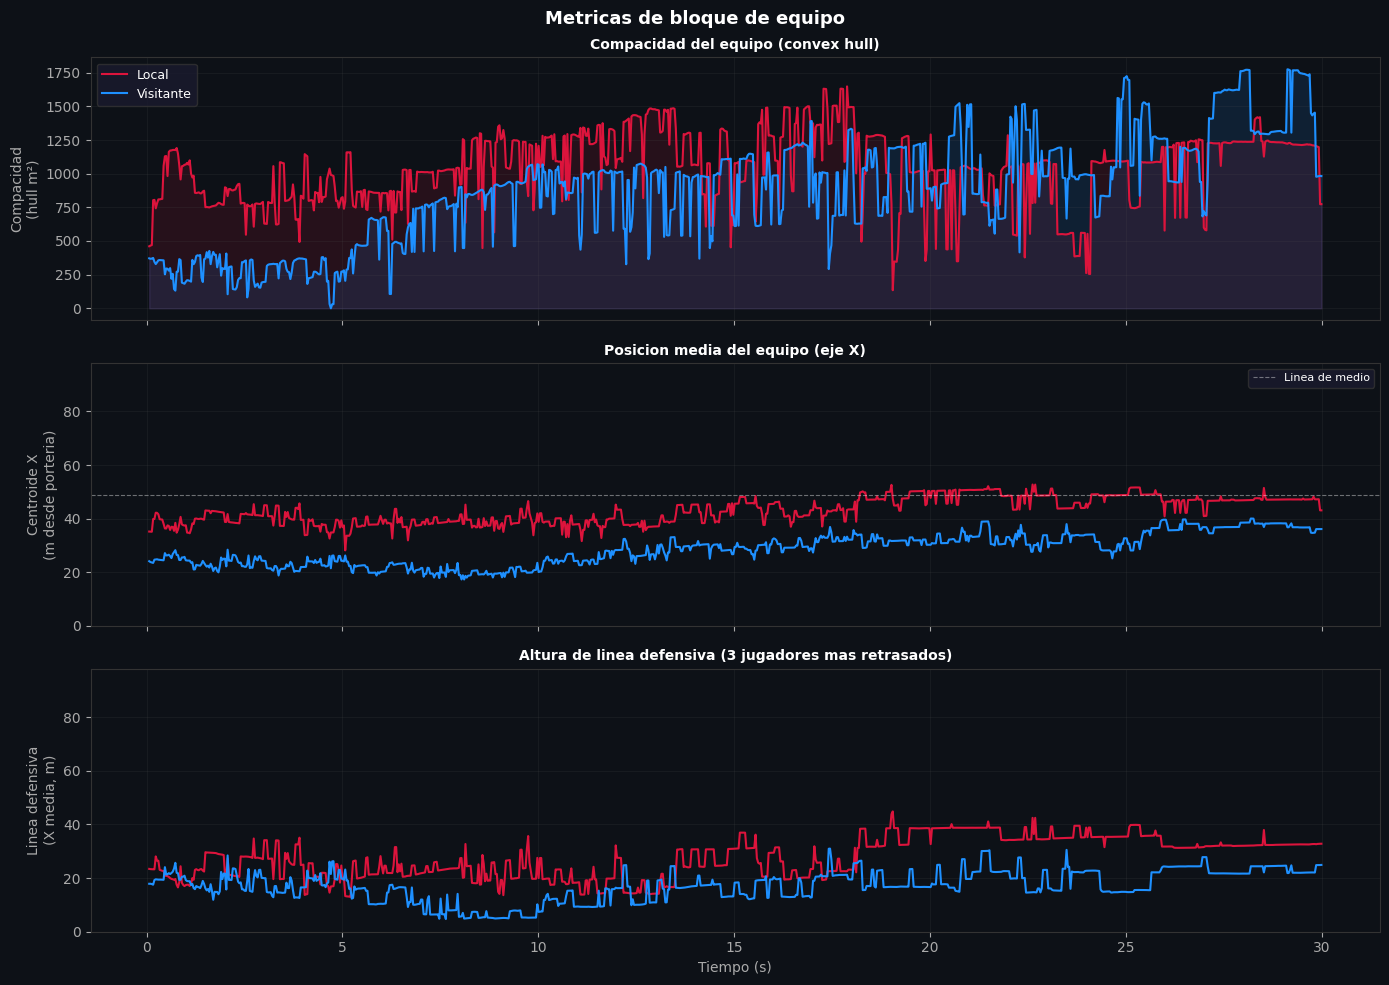


── Compacidad media (hull m²) ──
  Local    : 1044 m²  (min 134 – max 1648)
  Visitante: 878 m²  (min 0 – max 1775)

── Posicion media (centroide X, m) ──
  Local    : 43.1
  Visitante: 28.5


In [16]:
# ═══════════════════════════════════════════════════════════
#  COMPACIDAD Y CENTROIDE POR EQUIPO
#  Convex Hull · Centroide · Linea defensiva · Ancho efectivo
# ═══════════════════════════════════════════════════════════

def _team_metrics_per_frame(df_k, cls_list):
    """
    Para cada frame calcula:
      - centroid_x, centroid_y
      - hull_area  (area del convex hull en m2)
      - def_line_x (media X de los 4 jugadores mas retrasados)
      - width_m    (rango Y de los jugadores del equipo)
    """
    rows = []
    for frame, grp in df_k[df_k['cls'].isin(cls_list)].groupby('frame'):
        pts = grp[['x_m', 'y_m']].values
        if len(pts) < 2:
            continue
        cx, cy = pts[:, 0].mean(), pts[:, 1].mean()
        hull_area = 0.0
        if len(pts) >= 3:
            try:
                hull_area = ConvexHull(pts).volume   # volume = area en 2D
            except Exception:
                pass
        # Linea defensiva: los 3 jugadores de campo mas retrasados en X
        sorted_x = np.sort(pts[:, 0])
        def_line = float(sorted_x[:min(3, len(sorted_x))].mean())
        width_m  = float(pts[:, 1].max() - pts[:, 1].min())
        rows.append({
            'frame':      frame,
            'time_s':     grp['time_s'].iloc[0],
            'centroid_x': round(cx, 2),
            'centroid_y': round(cy, 2),
            'hull_area':  round(hull_area, 1),
            'def_line_x': round(def_line, 2),
            'width_m':    round(width_m, 2),
            'n_players':  len(pts),
        })
    return pd.DataFrame(rows)


home_metrics = _team_metrics_per_frame(df_known, TEAM_HOME)
away_metrics = _team_metrics_per_frame(df_known, TEAM_AWAY)

# ── Figura: compacidad y centroide en el tiempo ────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.patch.set_facecolor(DARK_BG)

for ax in axes:
    ax.set_facecolor(DARK_BG)
    ax.tick_params(colors='#aaa')
    ax.grid(alpha=0.15, color='#555')
    for sp in ax.spines.values(): sp.set_color('#333')

# Panel 1: area del convex hull
axes[0].plot(home_metrics['time_s'], home_metrics['hull_area'],
             color=COLOR_MAP['player_home'], lw=1.5, label='Local')
axes[0].plot(away_metrics['time_s'], away_metrics['hull_area'],
             color=COLOR_MAP['player_away'], lw=1.5, label='Visitante')
axes[0].fill_between(home_metrics['time_s'], home_metrics['hull_area'],
                      alpha=0.12, color=COLOR_MAP['player_home'])
axes[0].fill_between(away_metrics['time_s'], away_metrics['hull_area'],
                      alpha=0.12, color=COLOR_MAP['player_away'])
axes[0].set_ylabel('Compacidad\n(hull m²)', color='#aaa')
axes[0].legend(fontsize=9, facecolor='#1a1a2e', labelcolor='white',
               edgecolor='#333', framealpha=0.8)
axes[0].set_title('Compacidad del equipo (convex hull)', color='white',
                   fontsize=10, fontweight='bold')

# Panel 2: centroide X (posicion media horizontal)
axes[1].plot(home_metrics['time_s'], home_metrics['centroid_x'],
             color=COLOR_MAP['player_home'], lw=1.5)
axes[1].plot(away_metrics['time_s'], away_metrics['centroid_x'],
             color=COLOR_MAP['player_away'], lw=1.5)
axes[1].axhline(L_M / 2, color='white', lw=0.8, ls='--', alpha=0.4,
                label='Linea de medio')
axes[1].set_ylabel('Centroide X\n(m desde porteria)', color='#aaa')
axes[1].set_ylim(0, L_M)
axes[1].legend(fontsize=8, facecolor='#1a1a2e', labelcolor='white',
               edgecolor='#333', framealpha=0.8)
axes[1].set_title('Posicion media del equipo (eje X)', color='white',
                   fontsize=10, fontweight='bold')

# Panel 3: linea defensiva
axes[2].plot(home_metrics['time_s'], home_metrics['def_line_x'],
             color=COLOR_MAP['player_home'], lw=1.5, label='Local')
axes[2].plot(away_metrics['time_s'], away_metrics['def_line_x'],
             color=COLOR_MAP['player_away'], lw=1.5, label='Visitante')
axes[2].set_ylabel('Linea defensiva\n(X media, m)', color='#aaa')
axes[2].set_xlabel('Tiempo (s)', color='#aaa')
axes[2].set_ylim(0, L_M)
axes[2].set_title('Altura de linea defensiva (3 jugadores mas retrasados)',
                   color='white', fontsize=10, fontweight='bold')

fig.suptitle('Metricas de bloque de equipo', color='white',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Resumen estadístico
print("\n── Compacidad media (hull m²) ──")
print(f"  Local    : {home_metrics['hull_area'].mean():.0f} m²  "
      f"(min {home_metrics['hull_area'].min():.0f} – max {home_metrics['hull_area'].max():.0f})")
print(f"  Visitante: {away_metrics['hull_area'].mean():.0f} m²  "
      f"(min {away_metrics['hull_area'].min():.0f} – max {away_metrics['hull_area'].max():.0f})")
print(f"\n── Posicion media (centroide X, m) ──")
print(f"  Local    : {home_metrics['centroid_x'].mean():.1f}")
print(f"  Visitante: {away_metrics['centroid_x'].mean():.1f}")


## 4 · Velocidad y sprints
Velocidad calculada de la derivada de las trayectorias (suavizada 3 frames).
Sprint = velocidad ≥ `SPRINT_MS` m/s durante ≥ 8 frames consecutivos.

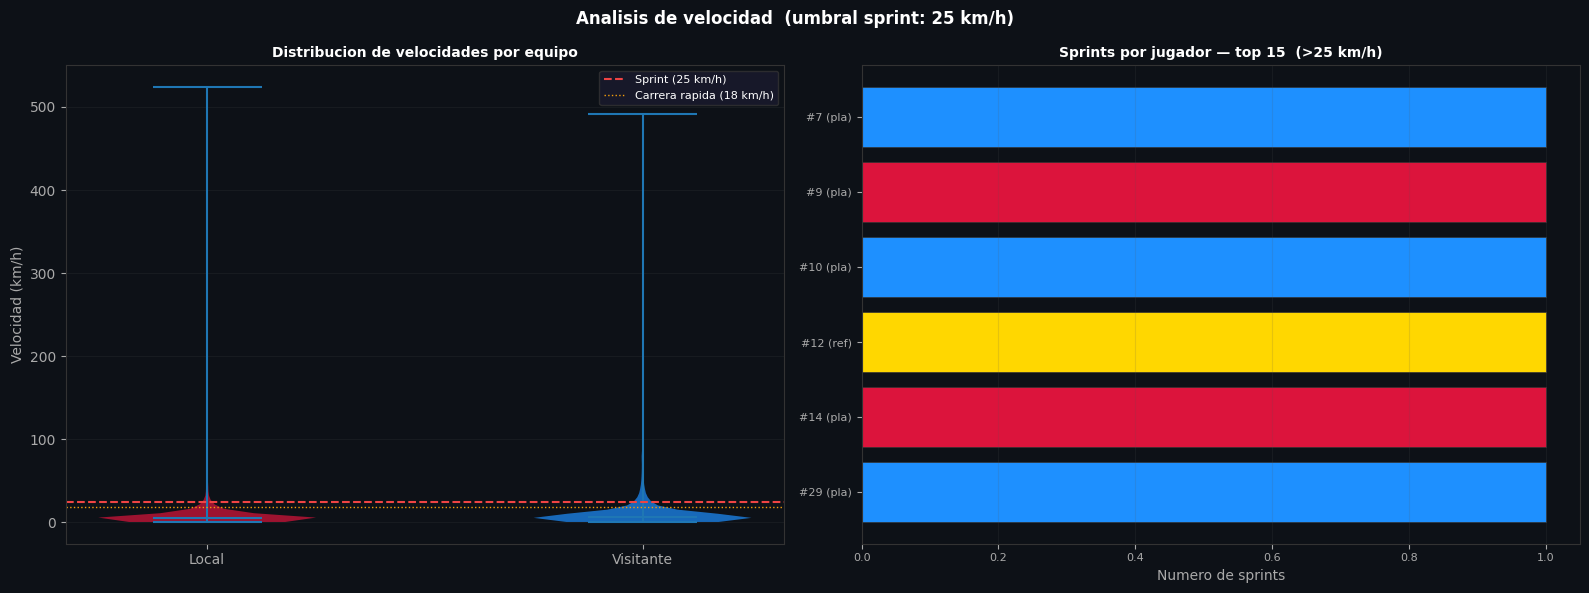

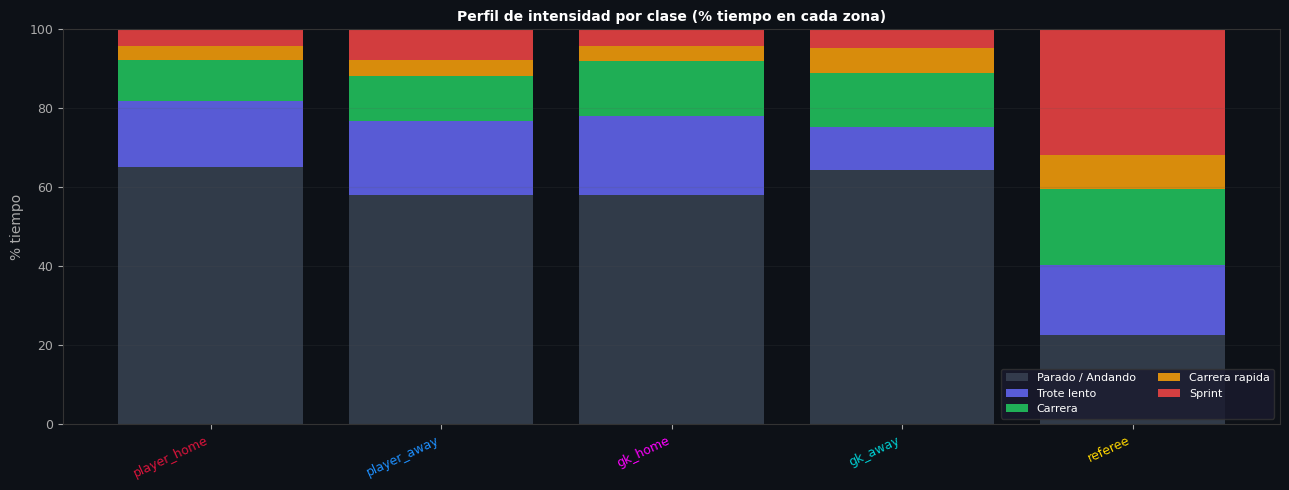

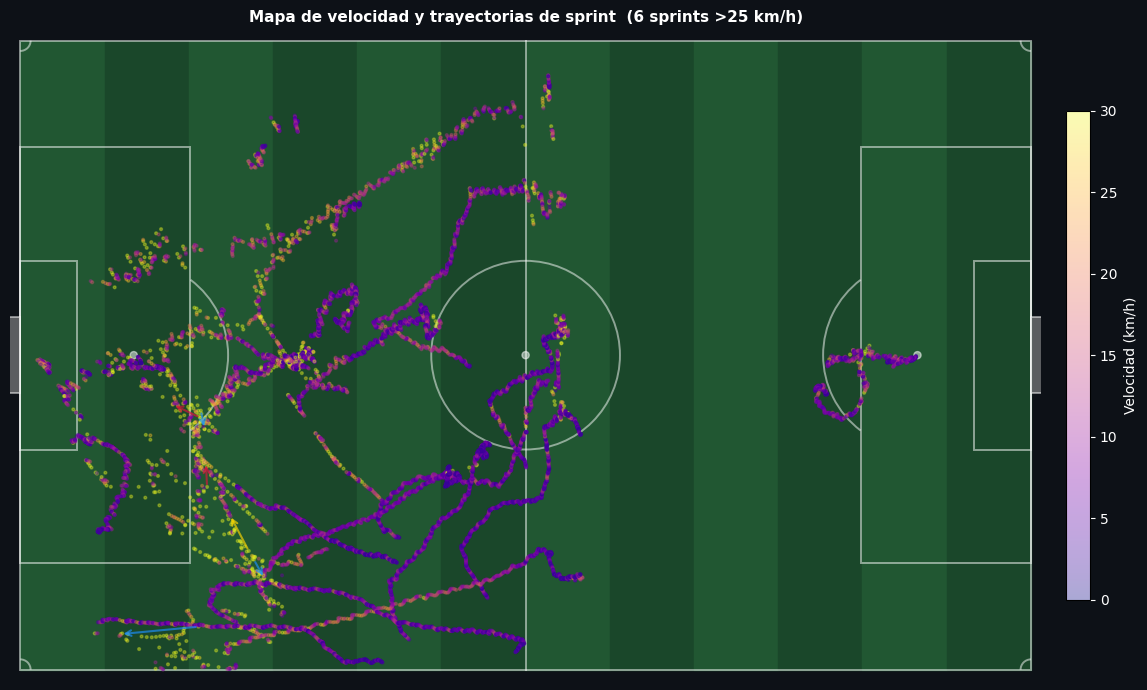


═══════════════════════════════════════════════════════
  Clase            V.media   V.max   Sprints
  ──────────────────────────────────────────
  player_home        8.2 kmh  523.9         2
  player_away       11.3 kmh  491.1         3
  gk_home            8.3 kmh  138.2         0
  gk_away            9.9 kmh  328.1         0
  referee           33.1 kmh  258.6         1
═══════════════════════════════════════════════════════

  Max velocidad registrada: 323.6 km/h  (ID #7)
  Sprint mas largo: 8 m  (0.6 s)


In [17]:
# ═══════════════════════════════════════════════════════════
#  VELOCIDAD Y SPRINTS (todas las velocidades en km/h)
#  Distribucion · Mapa de velocidad · Sprints detectados
# ═══════════════════════════════════════════════════════════

# ── Calcular velocidad si no viene en el CSV ──────────────
if 'speed_ms' not in df_known.columns or df_known['speed_ms'].max() < 0.01:
    _speeds = []
    for gid, grp in df_known.groupby('gid'):
        grp = grp.sort_values('frame').copy()
        dx  = grp['x_m'].diff().fillna(0)
        dy  = grp['y_m'].diff().fillna(0)
        dt  = grp['frame'].diff().fillna(1) / FPS
        v   = np.sqrt(dx**2 + dy**2) / dt.replace(0, np.nan)
        v   = v.fillna(0).clip(0, 12.0)
        grp['speed_ms'] = v.rolling(3, min_periods=1, center=True).mean().values
        _speeds.append(grp)
    df_known = pd.concat(_speeds).sort_values(['frame','gid']).reset_index(drop=True)

# Columna auxiliar en km/h
df_known['speed_kmh'] = df_known['speed_ms'] * MS_TO_KMH


# ── Deteccion de sprints ───────────────────────────────────
def _detect_sprints(df_g, sprint_ms=SPRINT_MS, min_frames=8):
    sprints = []
    for gid, grp in df_g.groupby('gid'):
        grp  = grp.sort_values('frame').reset_index(drop=True)
        cls  = grp['cls'].mode()[0]
        in_s, start_i = False, 0
        for i, row in grp.iterrows():
            if row['speed_ms'] >= sprint_ms:
                if not in_s: in_s, start_i = True, i
            else:
                if in_s:
                    dur = i - start_i
                    if dur >= min_frames:
                        seg  = grp.iloc[start_i:i]
                        dx   = seg['x_m'].iloc[-1] - seg['x_m'].iloc[0]
                        dy   = seg['y_m'].iloc[-1] - seg['y_m'].iloc[0]
                        sprints.append({
                            'gid':          gid,
                            'cls':          cls,
                            'start_frame':  int(grp.iloc[start_i]['frame']),
                            'end_frame':    int(grp.iloc[i-1]['frame']),
                            'duration_s':   round(dur / FPS, 2),
                            'max_kmh':      round(seg['speed_ms'].max() * MS_TO_KMH, 1),
                            'dist_m':       round(np.sqrt(dx**2 + dy**2), 1),
                        })
                    in_s = False
    return pd.DataFrame(sprints)

df_sprints = _detect_sprints(df_known)

# Zonas de intensidad
def _intensity_zone(kmh):
    if kmh < 7:    return 'Parado / Andando'
    if kmh < JOG_KMH:  return 'Trote lento'
    if kmh < RUN_KMH:  return 'Carrera'
    if kmh < SPRINT_KMH: return 'Carrera rapida'
    return 'Sprint'

df_known['intensity'] = df_known['speed_kmh'].apply(_intensity_zone)

INTENSITY_ORDER  = ['Parado / Andando', 'Trote lento', 'Carrera',
                    'Carrera rapida', 'Sprint']
INTENSITY_COLORS = ['#374151', '#6366f1', '#22c55e', '#f59e0b', '#ef4444']

# ── Figura 1: distribucion por intensidad + top sprints ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(DARK_BG)

# Panel izquierdo: violinplot velocidad km/h
ax_v = axes[0]
ax_v.set_facecolor(DARK_BG)
for sp in ax_v.spines.values(): sp.set_color('#333')

data_v, labels_v, colors_v = [], [], []
for cls_list, lbl, col in [(TEAM_HOME,'Local',COLOR_MAP['player_home']),
                            (TEAM_AWAY,'Visitante',COLOR_MAP['player_away'])]:
    spds = df_known[df_known['cls'].isin(cls_list)]['speed_kmh'].values
    spds = spds[spds > 0.5]
    if len(spds):
        data_v.append(spds); labels_v.append(lbl); colors_v.append(col)

if data_v:
    vp = ax_v.violinplot(data_v, showmedians=True)
    for body, col in zip(vp['bodies'], colors_v):
        body.set_facecolor(col); body.set_alpha(0.7)
    ax_v.axhline(SPRINT_KMH, color='#ef4444', lw=1.5, ls='--',
                 label=f'Sprint ({SPRINT_KMH:.0f} km/h)')
    ax_v.axhline(RUN_KMH,    color='#f59e0b', lw=1.0, ls=':',
                 label=f'Carrera rapida ({RUN_KMH:.0f} km/h)')
    ax_v.set_xticks(range(1, len(labels_v)+1))
    ax_v.set_xticklabels(labels_v, color='#aaa', fontsize=10)

ax_v.set_ylabel('Velocidad (km/h)', color='#aaa')
ax_v.tick_params(colors='#aaa')
ax_v.grid(axis='y', alpha=0.15, color='#555')
ax_v.legend(fontsize=8, facecolor='#1a1a2e', labelcolor='white',
            edgecolor='#333', framealpha=0.8)
ax_v.set_title('Distribucion de velocidades por equipo', color='white',
               fontsize=10, fontweight='bold')

# Panel derecho: barras de sprints por clase
ax_s = axes[1]
ax_s.set_facecolor(DARK_BG)
for sp in ax_s.spines.values(): sp.set_color('#333')

if len(df_sprints):
    sp_cnt = df_sprints.groupby(['gid','cls']).size().reset_index(name='n')
    sp_cnt = sp_cnt.sort_values('n', ascending=False).head(15)
    ax_s.barh(
        [f"#{int(r.gid)} ({r.cls[:3]})" for r in sp_cnt.itertuples()],
        sp_cnt['n'],
        color=[COLOR_MAP.get(r.cls,'#aaa') for r in sp_cnt.itertuples()],
        edgecolor='#333', lw=0.5
    )
    ax_s.invert_yaxis()
    ax_s.set_xlabel('Numero de sprints', color='#aaa')
    ax_s.tick_params(colors='#aaa', labelsize=8)
    ax_s.grid(axis='x', alpha=0.15, color='#555')

ax_s.set_title(f'Sprints por jugador — top 15  (>{SPRINT_KMH:.0f} km/h)',
               color='white', fontsize=10, fontweight='bold')

fig.suptitle(f'Analisis de velocidad  (umbral sprint: {SPRINT_KMH:.0f} km/h)',
             color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


# ── Figura 2: barras apiladas de intensidad por clase ────
fig2, ax2 = plt.subplots(figsize=(13, 5))
fig2.patch.set_facecolor(DARK_BG)
ax2.set_facecolor(DARK_BG)
for sp in ax2.spines.values(): sp.set_color('#333')

# % tiempo en cada zona por clase
inten_pct = (df_known.groupby(['cls','intensity']).size()
             .unstack(fill_value=0)
             .reindex(columns=INTENSITY_ORDER, fill_value=0))
inten_pct = inten_pct.div(inten_pct.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(CLASSES_ORDER))
for zone, zcol in zip(INTENSITY_ORDER, INTENSITY_COLORS):
    vals = [inten_pct.loc[c, zone] if c in inten_pct.index else 0
            for c in CLASSES_ORDER]
    ax2.bar(CLASSES_ORDER, vals, bottom=bottom, color=zcol, label=zone, alpha=0.88)
    bottom += np.array(vals)

ax2.set_ylim(0, 100)
ax2.set_ylabel('% tiempo', color='#aaa')
ax2.tick_params(colors='#aaa', labelsize=9)
ax2.set_xticklabels(CLASSES_ORDER, rotation=25, ha='right')
for tick, cls_n in zip(ax2.get_xticklabels(), CLASSES_ORDER):
    tick.set_color(COLOR_MAP.get(cls_n, 'white'))
ax2.grid(axis='y', alpha=0.15, color='#555')
ax2.legend(fontsize=8, facecolor='#1a1a2e', labelcolor='white',
           edgecolor='#333', framealpha=0.8, loc='lower right', ncol=2)
ax2.set_title('Perfil de intensidad por clase (% tiempo en cada zona)',
              color='white', fontsize=10, fontweight='bold')
fig2.patch.set_facecolor(DARK_BG)
plt.tight_layout()
plt.show()


# ── Figura 3: mapa de velocidad sobre el campo ───────────
fig3, ax3 = plt.subplots(figsize=(13, 7))
fig3.patch.set_facecolor(DARK_BG)
draw_pitch(ax3, alpha_lines=0.5)

sc_data = df_known[df_known['speed_kmh'] > 2]
sc = ax3.scatter(sc_data['x_m'], sc_data['y_m'],
                 c=sc_data['speed_kmh'], cmap='plasma',
                 s=4, alpha=0.35, vmin=0, vmax=30, zorder=5)
cbar = fig3.colorbar(sc, ax=ax3, fraction=0.02, pad=0.02)
cbar.set_label('Velocidad (km/h)', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

# Flechas de sprints
if len(df_sprints):
    for _, sp in df_sprints.iterrows():
        seg = df_known[(df_known['gid'] == sp['gid']) &
                       (df_known['frame'] >= sp['start_frame']) &
                       (df_known['frame'] <= sp['end_frame'])]
        if len(seg) >= 2:
            x0, y0 = seg.iloc[0][['x_m','y_m']]
            x1, y1 = seg.iloc[-1][['x_m','y_m']]
            ax3.annotate('', xy=(x1,y1), xytext=(x0,y0),
                         arrowprops=dict(arrowstyle='->',
                                         color=COLOR_MAP.get(sp['cls'],'#aaa'),
                                         lw=1.5, alpha=0.65), zorder=6)

ax3.set_title(f'Mapa de velocidad y trayectorias de sprint  '
              f'({len(df_sprints)} sprints >{SPRINT_KMH:.0f} km/h)',
              color='white', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


# ── Resumen estadístico ───────────────────────────────────
print(f"\n{'═'*55}")
print(f"  {'Clase':<14}  {'V.media':>8}  {'V.max':>6}  {'Sprints':>8}")
print(f"  {'─'*42}")
for cls_n in CLASSES_ORDER:
    sub = df_known[df_known['cls'] == cls_n]
    if len(sub) == 0: continue
    vm  = sub['speed_kmh'].mean()
    vx  = sub['speed_kmh'].max()
    nsp = len(df_sprints[df_sprints['cls'] == cls_n]) if len(df_sprints) else 0
    print(f"  {cls_n:<14}  {vm:>6.1f} kmh  {vx:>5.1f}  {nsp:>8}")
print(f"{'═'*55}")

if len(df_sprints):
    print(f"\n  Max velocidad registrada: "
          f"{df_sprints['max_kmh'].max():.1f} km/h  "
          f"(ID #{int(df_sprints.loc[df_sprints['max_kmh'].idxmax(),'gid'])})")
    print(f"  Sprint mas largo: "
          f"{df_sprints['dist_m'].max():.0f} m  "
          f"({df_sprints['duration_s'].max():.1f} s)")


## 5 · Zonas de control — Voronoi interactivo
Cada zona del campo está coloreada según el jugador más cercano (control de espacio instantáneo). Usa el slider para navegar por el partido.

In [ ]:
# ═══════════════════════════════════════════════════════════
#  ZONAS DE CONTROL — DIAGRAMA DE VORONOI
#  Muestra quien controla cada zona del campo en un instante
# ═══════════════════════════════════════════════════════════

import ipywidgets as widgets
from IPython.display import display

# ── Colores Voronoi ───────────────────────────────────────
VORONOI_ALPHA = 0.35

def _fill_voronoi_on_field(ax, players, lm=L_M, am=A_M, res=200):
    """
    Rasteriza el diagrama de Voronoi sobre el campo usando
    nearest-neighbor en una cuadricula (no depende de scipy.Voronoi
    para evitar problemas con pocos puntos).
    """
    if len(players) < 2:
        return
    xs = np.linspace(0, lm, res)
    ys = np.linspace(0, am, res)
    xx, yy = np.meshgrid(xs, ys)
    grid   = np.stack([xx.ravel(), yy.ravel()], axis=1)  # (res², 2)

    pts  = np.array([[p['x'], p['y']] for p in players])
    cols = np.array([p['color'] for p in players])

    # Distancia de cada punto del grid a cada jugador
    dists   = np.linalg.norm(grid[:, None, :] - pts[None, :, :], axis=2)
    nearest = np.argmin(dists, axis=1)

    # Renderizar como imagen RGBA
    from matplotlib.colors import to_rgba
    img_flat = np.array([to_rgba(cols[idx], alpha=VORONOI_ALPHA)
                          for idx in nearest])
    img = img_flat.reshape(res, res, 4)
    ax.imshow(img, extent=[0, lm, am, 0], origin='upper',
              aspect='auto', zorder=3, interpolation='nearest')


def _draw_voronoi_frame(frame_idx):
    df_f = df_known[df_known['frame'] == frame_idx]
    if len(df_f) == 0:
        print(f"Sin datos para frame {frame_idx}")
        return

    players = []
    for _, row in df_f.iterrows():
        players.append({
            'x':     row['x_m'],
            'y':     row['y_m'],
            'cls':   row['cls'],
            'gid':   int(row['gid']),
            'color': COLOR_MAP.get(row['cls'], '#888'),
        })

    fig, ax = plt.subplots(figsize=(13, 7))
    fig.patch.set_facecolor(DARK_BG)
    draw_pitch(ax, alpha_lines=0.7)

    _fill_voronoi_on_field(ax, players)

    # Posiciones de jugadores encima
    for p in players:
        col = COLOR_MAP.get(p['cls'], '#888')
        ax.scatter(p['x'], p['y'], color=col, s=120, zorder=7,
                   edgecolors='white', linewidths=0.8)
        ax.text(p['x'], p['y'] - 1.8, f"#{p['gid']}", color='white',
                fontsize=7, ha='center', fontweight='bold', zorder=8)

    # Balon si hay datos
    if len(df_ball):
        ball_f = df_ball[df_ball['frame'] == frame_idx]
        if len(ball_f):
            bx, by = ball_f.iloc[0][['x_m', 'y_m']]
            ax.scatter(bx, by, color=COLOR_MAP['ball'], s=180,
                       marker='o', zorder=9, edgecolors='white', lw=1.5)

    # Leyenda
    handles = [mpatches.Patch(color=COLOR_MAP[c], label=c, alpha=0.8)
               for c in ['player_home', 'player_away', 'gk_home', 'gk_away', 'referee']
               if c in df_f['cls'].values]
    ax.legend(handles=handles, loc='lower right', fontsize=8,
              facecolor='#1a1a2e', labelcolor='white',
              edgecolor='#333', framealpha=0.8)

    t_s = df_f['time_s'].iloc[0]
    ax.set_title(f'Zonas de control (Voronoi)  —  frame {frame_idx}  |  t={t_s:.1f} s',
                 color='white', fontsize=11, fontweight='bold')
    plt.tight_layout()
    with out_vor:
        out_vor.clear_output(wait=True)
        display(fig)
        plt.close(fig)


# ── Widget ────────────────────────────────────────────────
frames_avail = sorted(df_known['frame'].unique())
slider_vor   = widgets.IntSlider(
    value=frames_avail[0], min=frames_avail[0],
    max=frames_avail[-1], step=1,
    description='Frame:', continuous_update=False,
    layout=widgets.Layout(width='600px'),
    style={'description_width': '60px'}
)
out_vor = widgets.Output()

def _on_vor(_): _draw_voronoi_frame(slider_vor.value)
slider_vor.observe(_on_vor, names='value')

display(widgets.VBox([slider_vor, out_vor]))
_draw_voronoi_frame(frames_avail[len(frames_avail)//2])


## 6 · Pressing e intensidad defensiva
Si hay datos de balón: pressing index = fracción de defensores a menos de `PRESS_DIST` metros del portador.

Sin balón: distancia inter-equipo media como proxy de presión.

Sin datos de balon — pressing index no disponible.
Sin datos de pressing (se necesita deteccion de balon).
Mostrando estadisticas de distancia inter-equipo como alternativa.


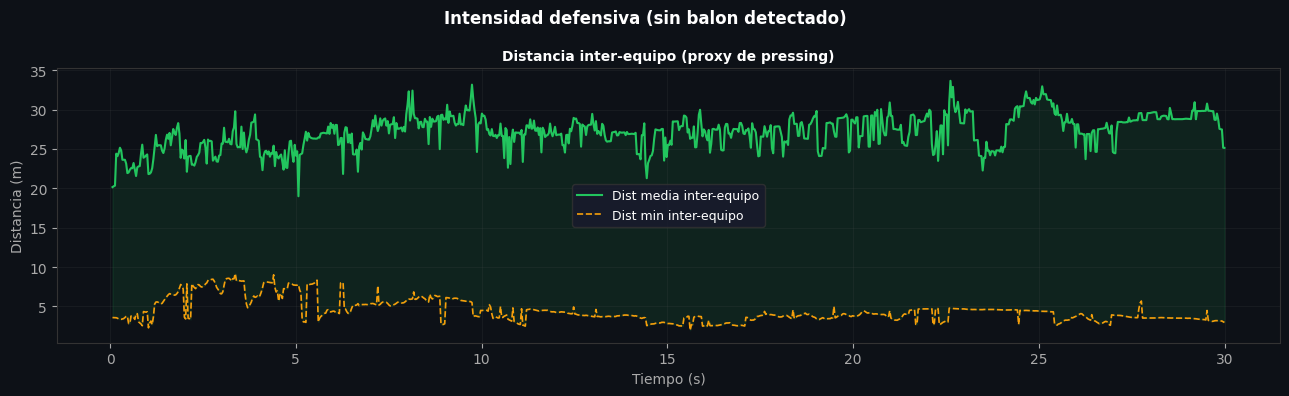


Distancia inter-equipo media: 27.2 m


In [19]:
# ═══════════════════════════════════════════════════════════
#  PRESION E INTENSIDAD DEFENSIVA
#  Pressing index · PPDA aproximado · Linea de pressing
# ═══════════════════════════════════════════════════════════

# ── Pressing index por frame ──────────────────────────────
def _pressing_index(df_k, df_b, press_dist=PRESS_DIST):
    """
    Para cada frame con balon, cuenta cuantos defensores del
    equipo sin posesion estan a menos de press_dist metros del
    portador estimado (jugador mas cercano al balon).

    Devuelve DataFrame: {frame, time_s, possession, press_count, press_index}
    press_index = press_count / n_players_team (0-1)
    """
    if len(df_b) == 0:
        print("Sin datos de balon — pressing index no disponible.")
        return pd.DataFrame()

    rows = []
    for _, ball_row in df_b.iterrows():
        frame = ball_row['frame']
        bx, by = ball_row['x_m'], ball_row['y_m']
        df_f  = df_k[df_k['frame'] == frame]
        if len(df_f) == 0:
            continue

        # Equipo con posesion: el mas cercano al balon
        df_f = df_f.copy()
        df_f['d_ball'] = np.sqrt(
            (df_f['x_m'] - bx)**2 + (df_f['y_m'] - by)**2)
        nearest = df_f.loc[df_f['d_ball'].idxmin(), 'cls']
        possess = 'home' if nearest in TEAM_HOME else 'away'

        # Equipo defensor
        defend_cls = TEAM_AWAY if possess == 'home' else TEAM_HOME
        defenders  = df_f[df_f['cls'].isin(defend_cls)]
        if len(defenders) == 0:
            continue

        # Cuantos defensores presionan (< press_dist del balon)
        pressing = defenders[defenders['d_ball'] < press_dist]
        n_press  = len(pressing)
        n_def    = len(defenders)
        rows.append({
            'frame':        frame,
            'time_s':       ball_row['time_s'],
            'possession':   possess,
            'press_count':  n_press,
            'press_index':  round(n_press / n_def, 3) if n_def else 0,
            'n_defenders':  n_def,
        })
    return pd.DataFrame(rows)


df_press = _pressing_index(df_known, df_ball)

if len(df_press) == 0:
    print("Sin datos de pressing (se necesita deteccion de balon).")
    print("Mostrando estadisticas de distancia inter-equipo como alternativa.")

    # Alternativa sin balon: distancia media entre equipos
    def _interteam_dist(df_k):
        rows = []
        for frame, grp in df_k.groupby('frame'):
            home = grp[grp['cls'].isin(TEAM_HOME)][['x_m', 'y_m']].values
            away = grp[grp['cls'].isin(TEAM_AWAY)][['x_m', 'y_m']].values
            if len(home) == 0 or len(away) == 0:
                continue
            from scipy.spatial.distance import cdist as _cdist
            D = _cdist(home, away)
            rows.append({'frame': frame,
                         'time_s': grp['time_s'].iloc[0],
                         'mean_dist': round(D.mean(), 2),
                         'min_dist': round(D.min(), 2)})
        return pd.DataFrame(rows)

    df_interdist = _interteam_dist(df_known)
    if len(df_interdist):
        fig, ax = plt.subplots(figsize=(13, 4))
        fig.patch.set_facecolor(DARK_BG); ax.set_facecolor(DARK_BG)
        for sp in ax.spines.values(): sp.set_color('#333')
        ax.plot(df_interdist['time_s'], df_interdist['mean_dist'],
                color='#22c55e', lw=1.5, label='Dist media inter-equipo')
        ax.plot(df_interdist['time_s'], df_interdist['min_dist'],
                color='#f59e0b', lw=1.2, ls='--', label='Dist min inter-equipo')
        ax.fill_between(df_interdist['time_s'], df_interdist['min_dist'],
                        df_interdist['mean_dist'], alpha=0.1, color='#22c55e')
        ax.set_xlabel('Tiempo (s)', color='#aaa')
        ax.set_ylabel('Distancia (m)', color='#aaa')
        ax.tick_params(colors='#aaa')
        ax.grid(alpha=0.15, color='#555')
        ax.legend(fontsize=9, facecolor='#1a1a2e', labelcolor='white',
                  edgecolor='#333', framealpha=0.8)
        ax.set_title('Distancia inter-equipo (proxy de pressing)',
                     color='white', fontsize=10, fontweight='bold')
        fig.suptitle('Intensidad defensiva (sin balon detectado)',
                     color='white', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
        print(f"\nDistancia inter-equipo media: {df_interdist['mean_dist'].mean():.1f} m")

else:
    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    fig.patch.set_facecolor(DARK_BG)

    for ax in axes:
        ax.set_facecolor(DARK_BG)
        ax.tick_params(colors='#aaa')
        ax.grid(alpha=0.15, color='#555')
        for sp in ax.spines.values(): sp.set_color('#333')

    # Panel 1: pressing index suavizado
    roll = df_press['press_index'].rolling(15, min_periods=1, center=True).mean()
    axes[0].fill_between(df_press['time_s'], roll, alpha=0.3, color='#ef4444')
    axes[0].plot(df_press['time_s'], roll, color='#ef4444', lw=1.5)
    axes[0].axhline(roll.mean(), color='white', lw=1, ls='--',
                    label=f'Media: {roll.mean():.2f}')
    axes[0].set_ylabel('Pressing index\n(0-1)', color='#aaa')
    axes[0].set_ylim(0, 1)
    axes[0].legend(fontsize=8, facecolor='#1a1a2e', labelcolor='white',
                   edgecolor='#333')
    axes[0].set_title('Pressing index en el tiempo', color='white',
                      fontsize=10, fontweight='bold')

    # Panel 2: posesion estimada
    home_pos = df_press[df_press['possession'] == 'home']['time_s']
    away_pos = df_press[df_press['possession'] == 'away']['time_s']
    axes[1].scatter(home_pos, np.ones(len(home_pos)) * 1,
                    color=COLOR_MAP['player_home'], s=8, alpha=0.6,
                    label='Local con balon')
    axes[1].scatter(away_pos, np.ones(len(away_pos)) * 0,
                    color=COLOR_MAP['player_away'], s=8, alpha=0.6,
                    label='Visitante con balon')
    axes[1].set_yticks([0, 1])
    axes[1].set_yticklabels(['Visitante', 'Local'], color='#aaa')
    axes[1].set_xlabel('Tiempo (s)', color='#aaa')
    axes[1].legend(fontsize=8, facecolor='#1a1a2e', labelcolor='white',
                   edgecolor='#333')
    axes[1].set_title('Posesion estimada (jugador mas cercano al balon)',
                      color='white', fontsize=10, fontweight='bold')

    fig.suptitle('Analisis de pressing e intensidad defensiva',
                 color='white', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    poss_home = (df_press['possession'] == 'home').mean()
    print(f"\n── Posesion estimada ──")
    print(f"  Local    : {poss_home*100:.1f}%")
    print(f"  Visitante: {(1-poss_home)*100:.1f}%")
    print(f"\n── Pressing index medio (equipo defensor) ──")
    print(f"  Global: {df_press['press_index'].mean():.3f}")


## 7 · Formación y posiciones medias
La posición media de cada jugador revela la estructura táctica del equipo. Solo se usan los **11 jugadores con mayor presencia** por equipo (el once titular real), descartando IDs fragmentados o suplentes.

La elipse muestra la dispersión (1σ). Las líneas conectan jugadores de la misma línea táctica.

  Jugadores seleccionados: 11 (de 18 con >20 frames)
  Jugadores seleccionados: 11 (de 16 con >20 frames)

══════════════════════════════════════════════════
  Local  —  Formacion detectada: 4-4-2
  (distribucion real de lineas: 4-3-3-1)
  Linea     X medio  N jugadores  IDs
  ─────────────────────────────────────────────
  Portero     26.1m        4  #9 #36 #22 #44
  Defensa     39.7m        3  #1 #6 #4
  Medio       48.6m        3  #2 #5 #13
  Ataque      81.4m        1  #17

  Distancias entre lineas:
    Portero → Defensa: 13.6 m
    Defensa → Medio: 8.9 m
    Medio → Ataque: 32.8 m

══════════════════════════════════════════════════
  Visitante  —  Formacion detectada: 4-4-2
  (distribucion real de lineas: 3-3-4-1)
  Linea     X medio  N jugadores  IDs
  ─────────────────────────────────────────────
  Portero     11.3m        3  #31 #8 #13
  Defensa     24.9m        3  #7 #29 #41
  Medio       34.4m        4  #10 #19 #16 #39
  Ataque      44.6m        1  #3

  Distancias entre lin

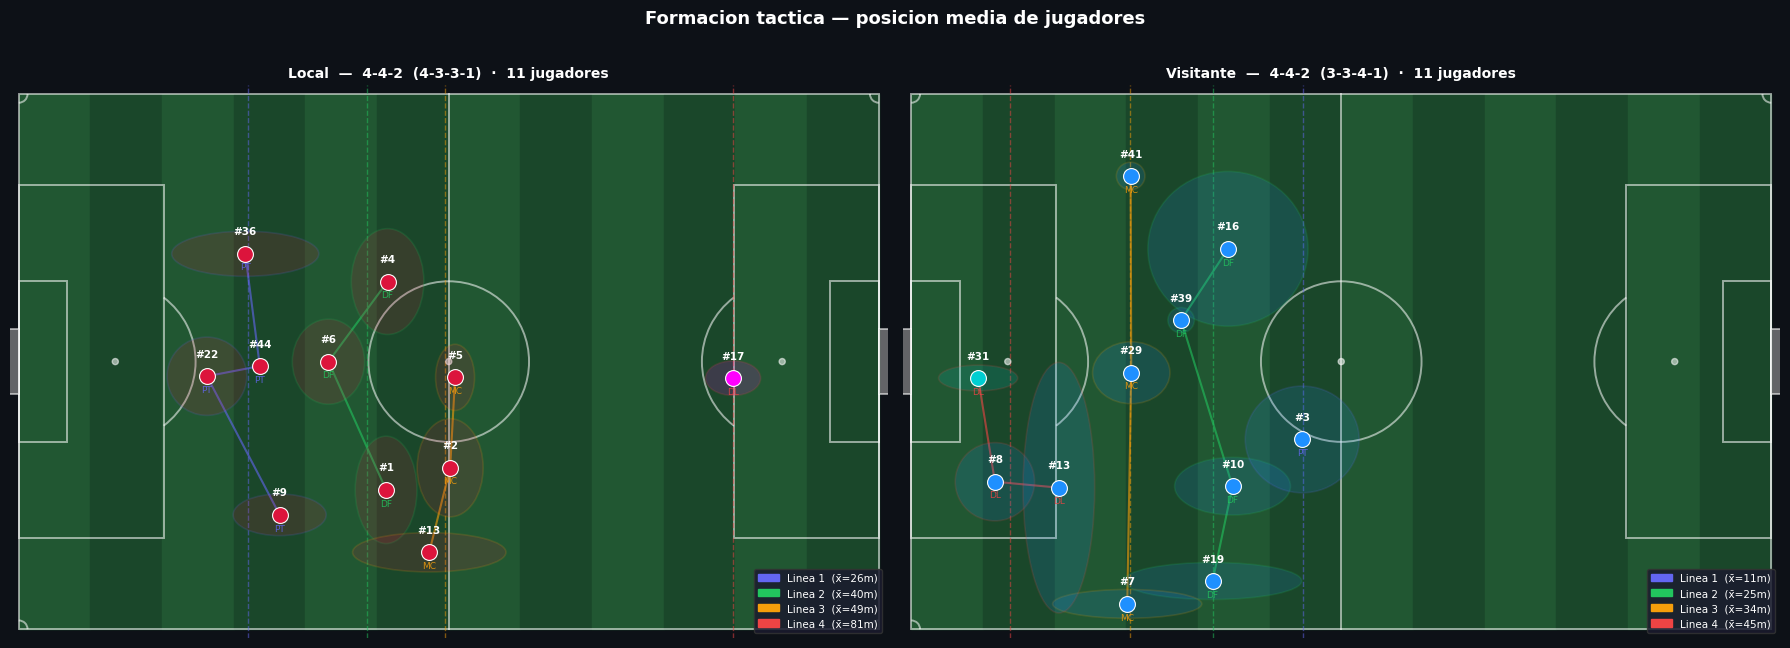


Figura guardada: formacion_tactica.png

────────────────────────────────────────────────
  Tramo            Local   Visitante
  ────────────────────────────────────
  PT→DEF          13.6 m      13.6 m
  DEF→MC           8.9 m       9.5 m
  MC→DL           32.8 m      10.2 m
  ────────────────────────────────────
  TOTAL           55.3 m      33.3 m


In [20]:
# ═══════════════════════════════════════════════════════════
#  FORMACION TACTICA
#  Deteccion automatica de formacion (4-3-3, 4-4-2, etc.)
#  Posiciones medias · Lineas · Distancias entre lineas
# ═══════════════════════════════════════════════════════════
from sklearn.cluster import KMeans as _KMeans
import warnings as _w; _w.filterwarnings('ignore')

# ── Parametros ────────────────────────────────────────────
MIN_FRAMES_PLAYER = 20    # minimo de frames para considerar un jugador
N_LINES           = 4     # numero de lineas de clustering (GK + DEF + MED + ATK)
MAX_PLAYERS_TEAM  = 11    # tomar solo los 11 con mas presencia (= once titular)

# Nombres de formaciones canonicas (se busca el mas cercano)
_FORMATION_NAMES = {
    (1, 4, 4, 2): '4-4-2',
    (1, 4, 3, 3): '4-3-3',
    (1, 4, 2, 3, 1): '4-2-3-1',
    (1, 3, 5, 2): '3-5-2',
    (1, 3, 4, 3): '3-4-3',
    (1, 5, 3, 2): '5-3-2',
    (1, 4, 1, 4, 1): '4-1-4-1',
    (1, 4, 5, 1): '4-5-1',
    (1, 3, 3, 3, 1): '3-3-3-1',
    (1, 4, 4, 1, 1): '4-4-1-1',
}

def _closest_formation(line_counts):
    """Devuelve el nombre de formacion mas parecido al vector de lineas."""
    counts = tuple(line_counts)
    if counts in _FORMATION_NAMES:
        return _FORMATION_NAMES[counts]
    # Buscar el mas cercano por distancia L1
    best, best_d = '?', 999
    for canon, name in _FORMATION_NAMES.items():
        # Alinear por longitud (comparar solo lineas comunes)
        n = min(len(canon), len(counts))
        d = sum(abs(a - b) for a, b in zip(canon[:n], counts[:n]))
        d += abs(len(canon) - len(counts)) * 2   # penalizar lineas extra/faltantes
        if d < best_d:
            best_d, best = d, name
    return best


def _avg_positions(df_k, cls_list, min_frames=MIN_FRAMES_PLAYER,
                   max_players=MAX_PLAYERS_TEAM):
    """
    Calcula la posicion media de cada jugador.
    Luego recorta a los `max_players` con mas presencia (frames detectados),
    que corresponden al once titular real.

    Prioridad: porteros primero (gk_home / gk_away), luego campo por presencia.
    """
    rows = []
    for gid, grp in df_k[df_k['cls'].isin(cls_list)].groupby('gid'):
        if len(grp) < min_frames:
            continue
        cls_mode = grp['cls'].mode()[0]
        rows.append({
            'gid':    gid,
            'cls':    cls_mode,
            'mean_x': round(grp['x_m'].mean(), 2),
            'mean_y': round(grp['y_m'].mean(), 2),
            'std_x':  round(grp['x_m'].std(), 2),
            'std_y':  round(grp['y_m'].std(), 2),
            'n':      len(grp),
        })
    df_out = pd.DataFrame(rows)
    if len(df_out) == 0:
        return df_out

    # Ordenar: porteros primero, luego por n descendente
    is_gk = df_out['cls'].str.startswith('gk')
    df_gk  = df_out[is_gk].nlargest(1, 'n')        # max 1 portero
    df_field = df_out[~is_gk].nlargest(max_players - len(df_gk), 'n')
    df_out = pd.concat([df_gk, df_field]).reset_index(drop=True)

    print(f"  Jugadores seleccionados: {len(df_out)} "
          f"(de {len(rows)} con >{min_frames} frames)")
    return df_out


def _detect_formation(avg_df, team_name='Equipo', n_lines=N_LINES,
                      is_inverted=False):
    """
    Detecta la formacion de un equipo a partir de las posiciones medias.

    Parametros
    ----------
    avg_df      : DataFrame con columnas mean_x, mean_y, gid, cls
    team_name   : nombre para los prints
    n_lines     : numero de lineas a detectar (normalmente 4 = GK+DEF+MED+ATK)
    is_inverted : True si el equipo ataca hacia la derecha (X invertido)

    Devuelve
    --------
    dict con: formation_str, lines, inter_line_distances, avg_df_with_line
    """
    if len(avg_df) < 4:
        print(f"  {team_name}: insuficientes jugadores ({len(avg_df)})")
        return None

    pts = avg_df[['mean_x']].values
    k   = min(n_lines, len(avg_df))
    km  = _KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(pts)

    avg_df = avg_df.copy()
    avg_df['line_raw'] = km.labels_

    # Ordenar lineas por X (de menor a mayor = del portero al delantero)
    line_centers = {i: km.cluster_centers_[i][0] for i in range(k)}
    sorted_lines = sorted(line_centers.keys(), key=lambda i: line_centers[i])
    line_rank    = {old: new for new, old in enumerate(sorted_lines)}
    avg_df['line'] = avg_df['line_raw'].map(line_rank)

    # Si el equipo ataca hacia la derecha, invertir el orden de lineas
    if is_inverted:
        max_line = avg_df['line'].max()
        avg_df['line'] = max_line - avg_df['line']

    # Resumen por linea
    lines = []
    for line_idx in sorted(avg_df['line'].unique()):
        grp = avg_df[avg_df['line'] == line_idx]
        lines.append({
            'line':     line_idx,
            'n':        len(grp),
            'mean_x':   round(grp['mean_x'].mean(), 1),
            'mean_y':   round(grp['mean_y'].mean(), 1),
            'players':  list(grp['gid'].values),
        })
    lines_df = pd.DataFrame(lines).sort_values('mean_x').reset_index(drop=True)

    # Distancias entre lineas consecutivas
    inter_dists = []
    for i in range(len(lines_df) - 1):
        d = abs(lines_df.iloc[i+1]['mean_x'] - lines_df.iloc[i]['mean_x'])
        inter_dists.append(round(d, 1))

    line_counts  = list(lines_df['n'])
    formation_str = _closest_formation(line_counts)
    raw_str       = '-'.join(str(n) for n in line_counts)

    return {
        'formation':        formation_str,
        'raw':              raw_str,
        'lines_df':         lines_df,
        'inter_dists':      inter_dists,
        'avg_df':           avg_df,
    }


# ── Calcular posiciones medias ────────────────────────────
avg_home = _avg_positions(df_known, TEAM_HOME)
avg_away = _avg_positions(df_known, TEAM_AWAY)

# Detectar si los equipos atacan a izquierda o derecha segun centroide
home_cx = avg_home['mean_x'].mean() if len(avg_home) else L_M / 2
away_cx = avg_away['mean_x'].mean() if len(avg_away) else L_M / 2
# El equipo con menor X medio ataca hacia la derecha (invertido en nuestra convencion)
home_inv = home_cx < away_cx

form_home = _detect_formation(avg_home, 'Local',     is_inverted=home_inv)
form_away = _detect_formation(avg_away, 'Visitante', is_inverted=(not home_inv))


# ── Print de resultados ───────────────────────────────────
def _print_formation(result, team_name):
    if result is None:
        return
    print(f"\n{'═'*50}")
    print(f"  {team_name}  —  Formacion detectada: {result['formation']}")
    print(f"  (distribucion real de lineas: {result['raw']})")
    print(f"  {'Linea':<8} {'X medio':>8} {'N jugadores':>12}  IDs")
    print(f"  {'─'*45}")
    line_names = {0: 'Portero', 1: 'Defensa', 2: 'Medio', 3: 'Ataque', 4: 'Segunda'}
    for i, row in result['lines_df'].iterrows():
        lname = line_names.get(i, f'L{i}')
        ids_str = ' '.join(f'#{int(g)}' for g in row['players'])
        print(f"  {lname:<8} {row['mean_x']:>7.1f}m {row['n']:>8}  {ids_str}")
    print(f"\n  Distancias entre lineas:")
    lnames = list(line_names.values())
    for i, d in enumerate(result['inter_dists']):
        ln1 = lnames[i] if i < len(lnames) else f'L{i}'
        ln2 = lnames[i+1] if i+1 < len(lnames) else f'L{i+1}'
        print(f"    {ln1} → {ln2}: {d:.1f} m")

_print_formation(form_home, 'Local')
_print_formation(form_away, 'Visitante')


# ── Figura: posiciones medias con formacion ───────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(DARK_BG)

LINE_COLORS = ['#6366f1', '#22c55e', '#f59e0b', '#ef4444', '#a855f7']

for ax, avg_df, result, team_cls, team_name, main_col in [
    (axes[0], avg_home, form_home, TEAM_HOME, 'Local',     COLOR_MAP['player_home']),
    (axes[1], avg_away, form_away, TEAM_AWAY, 'Visitante', COLOR_MAP['player_away']),
]:
    draw_pitch(ax, alpha_lines=0.55)

    if result is None or len(avg_df) == 0:
        ax.set_title(f'{team_name} — sin datos', color='white', fontsize=10)
        continue

    av = result['avg_df']

    # Dibujar lineas verticales (posicion media de cada linea)
    for _, lrow in result['lines_df'].iterrows():
        lcol = LINE_COLORS[int(lrow['line']) % len(LINE_COLORS)]
        ax.axvline(lrow['mean_x'], color=lcol, lw=1.0, ls='--', alpha=0.5, zorder=2)

    # Conectar jugadores de la misma linea con una linea horizontal
    for line_idx, grp in av.groupby('line'):
        lcol = LINE_COLORS[int(line_idx) % len(LINE_COLORS)]
        if len(grp) > 1:
            grp_s = grp.sort_values('mean_y')
            ax.plot(grp_s['mean_x'], grp_s['mean_y'],
                    color=lcol, lw=1.5, alpha=0.6, zorder=3)

    # Jugadores: elipse de dispersion + punto + ID + nombre de linea
    line_label_names = {0: 'PT', 1: 'DF', 2: 'MC', 3: 'DL', 4: '2a'}
    for _, row in av.iterrows():
        col   = COLOR_MAP.get(row['cls'], main_col)
        lcol  = LINE_COLORS[int(row['line']) % len(LINE_COLORS)]
        from matplotlib.patches import Ellipse as _E
        ell = _E((row['mean_x'], row['mean_y']),
                 width=row['std_x'] * 2, height=row['std_y'] * 2,
                 fill=True, facecolor=col, alpha=0.15,
                 edgecolor=lcol, lw=1.2, zorder=4)
        ax.add_patch(ell)
        ax.scatter(row['mean_x'], row['mean_y'],
                   color=col, s=130, zorder=6,
                   edgecolors='white', lw=0.8)
        ax.text(row['mean_x'], row['mean_y'] - 2.2,
                f"#{int(row['gid'])}", color='white', fontsize=7.5,
                ha='center', fontweight='bold', zorder=7)
        # Etiqueta de linea encima del jugador
        lname = line_label_names.get(int(row['line']), '')
        ax.text(row['mean_x'], row['mean_y'] + 1.8,
                lname, color=lcol, fontsize=6.5,
                ha='center', alpha=0.85, zorder=7)

    form_str = result['formation'] if result else '?'
    raw_str  = result['raw'] if result else ''
    ax.set_title(
        f"{team_name}  —  {form_str}  ({raw_str})  ·  {len(av)} jugadores",
        color='white', fontsize=10, fontweight='bold'
    )

    # Leyenda de lineas
    handles = [mpatches.Patch(color=LINE_COLORS[i], label=f"Linea {i+1}  "
                              f"(x̄={result['lines_df'].iloc[i]['mean_x']:.0f}m)")
               for i in range(len(result['lines_df']))]
    ax.legend(handles=handles, loc='lower right', fontsize=7.5,
              facecolor='#1a1a2e', labelcolor='white',
              edgecolor='#333', framealpha=0.85)

fig.suptitle('Formacion tactica — posicion media de jugadores',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('formacion_tactica.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print("\nFigura guardada: formacion_tactica.png")


# ── Tabla comparativa de distancias entre lineas ─────────
def _print_inter_table(result_h, result_a):
    if result_h is None or result_a is None:
        return
    lnames = ['PT→DEF', 'DEF→MC', 'MC→DL', 'DL→2a']
    print(f"\n{'─'*48}")
    print(f"  {'Tramo':<12}  {'Local':>8}  {'Visitante':>10}")
    print(f"  {'─'*36}")
    max_lines = max(len(result_h['inter_dists']), len(result_a['inter_dists']))
    for i in range(max_lines):
        dh = f"{result_h['inter_dists'][i]:.1f} m" if i < len(result_h['inter_dists']) else '—'
        da = f"{result_a['inter_dists'][i]:.1f} m" if i < len(result_a['inter_dists']) else '—'
        lbl = lnames[i] if i < len(lnames) else f'L{i}→L{i+1}'
        print(f"  {lbl:<12}  {dh:>8}  {da:>10}")
    print(f"  {'─'*36}")
    # Profundidad total (portero a delantero)
    tot_h = sum(result_h['inter_dists'])
    tot_a = sum(result_a['inter_dists'])
    print(f"  {'TOTAL':<12}  {tot_h:>6.1f} m  {tot_a:>8.1f} m")

_print_inter_table(form_home, form_away)


## 8 · Dominancia territorial y presión
Índice de control del juego frame a frame:

- **Azul hacia arriba** → equipo local dominando
- **Rojo hacia abajo** → equipo visitante dominando

El índice combina: posición media del equipo (40%), jugadores en el tercio atacante (35%), jugadores dentro del área (15%) y posición del balón si está disponible (10%).

El segundo panel muestra cuántos jugadores de cada equipo están dentro del área rival en cada momento. El tercero desglosa cada componente.

Deteccion de direccion de ataque:
  Local    centroide X = 42.7 m  → ataca hacia x=98
  Visitante centroide X = 28.7 m → ataca hacia x=0

Dominancia calculada: 898 frames
  Dominio local    : 0.0% del tiempo
  Dominio visitante: 100.0% del tiempo
  Indice medio: -0.462  (visitante domina globalmente)


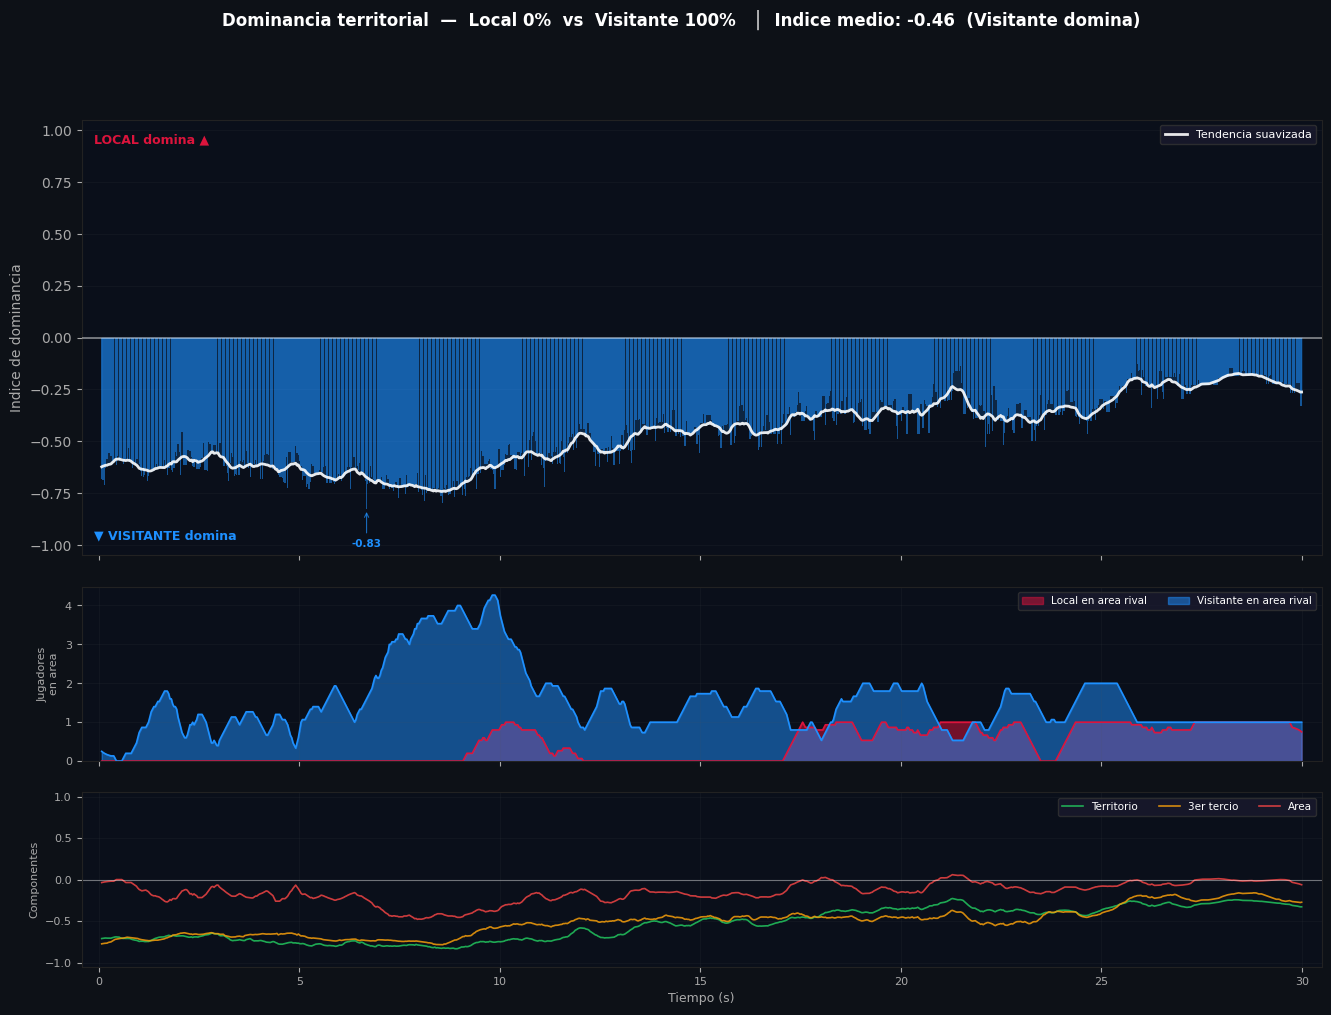

Figura guardada: dominancia_territorial.png


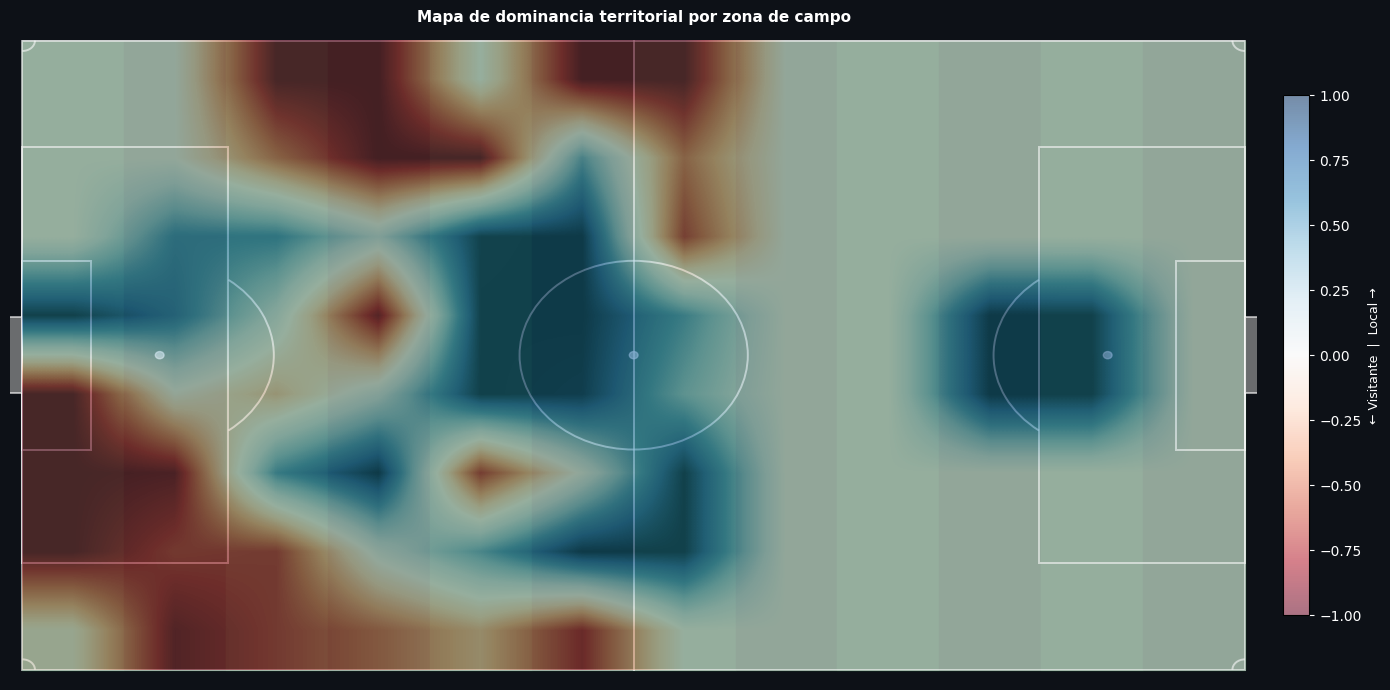


═══════════════════════════════════════════════════════
  Dominio temporal
  ────────────────────────────────────────
  Local domina   : 0.0% del tiempo
  Visitante domina: 100.0% del tiempo
  Indice medio   : -0.462

  Pico maximo local    : +-0.173  (t=28.4s)
  Pico maximo visitante: -0.742  (t=8.5s)

  Jugadores en area rival (media)
  Local    : 0.41 jugadores
  Visitante: 1.52 jugadores
═══════════════════════════════════════════════════════


In [21]:
# ═══════════════════════════════════════════════════════════
#  DOMINANCIA TERRITORIAL Y PRESION
#
#  Barras verticales: azul hacia arriba = local dominando
#                     rojo hacia abajo  = visitante dominando
#
#  El indice combina:
#    1. Territorio: posicion media de cada equipo en el campo
#    2. Presion ofensiva: jugadores en el tercio rival
#    3. Peligro: jugadores dentro del area rival (16.5m)
#    4. Posicion del balon (si disponible)
# ═══════════════════════════════════════════════════════════

import ipywidgets as widgets
from IPython.display import display

# ── Parametros ────────────────────────────────────────────
WINDOW_FRAMES  = 15    # suavizado temporal (frames por barra)
AREA_DEPTH     = 16.5  # profundidad del area grande (m)
THIRD_W        = L_M / 3.0  # anchura de cada tercio

# Pesos del indice compuesto (suman 1.0)
W_TERRITORY    = 0.40   # posicion media del equipo
W_ATTACK_THIRD = 0.35   # jugadores en tercio atacante
W_BOX          = 0.15   # jugadores dentro del area
W_BALL         = 0.10   # posicion del balon (solo si disponible)

# ── Detectar direccion de ataque ──────────────────────────
# El equipo con mayor centroid_x ataca hacia la derecha (porteria en x=L_M)
# El equipo con menor centroid_x ataca hacia la izquierda (porteria en x=0)
_cx_home = df_known[df_known['cls'].isin(TEAM_HOME)]['x_m'].mean()
_cx_away = df_known[df_known['cls'].isin(TEAM_AWAY)]['x_m'].mean()

# home_attack_x: coordenada X de la porteria que ataca el local
if _cx_home > _cx_away:
    home_attack_x = L_M    # local ataca hacia la porteria en x=L_M
    away_attack_x = 0.0
else:
    home_attack_x = 0.0    # local ataca hacia la porteria en x=0
    away_attack_x = L_M

print(f"Deteccion de direccion de ataque:")
print(f"  Local    centroide X = {_cx_home:.1f} m  → ataca hacia x={home_attack_x:.0f}")
print(f"  Visitante centroide X = {_cx_away:.1f} m → ataca hacia x={away_attack_x:.0f}")


# ── Calcular indice de dominancia por frame ───────────────
def _dominance_per_frame(df_k, df_b,
                          home_attack=home_attack_x,
                          away_attack=away_attack_x):
    """
    Devuelve DataFrame con una fila por frame:
      dom_index  : [-1, +1]  positivo = local domina, negativo = visitante
      dom_smooth : version suavizada
      + componentes individuales para desglose
    """
    rows = []
    frames_all = sorted(df_k['frame'].unique())

    for frame in frames_all:
        df_f  = df_k[df_k['frame'] == frame]
        home  = df_f[df_f['cls'].isin(TEAM_HOME)]
        away  = df_f[df_f['cls'].isin(TEAM_AWAY)]
        if len(home) == 0 and len(away) == 0:
            continue

        n_home = max(len(home), 1)
        n_away = max(len(away), 1)

        # 1. TERRITORIO: posicion normalizada centroide
        #    Si home ataca a la derecha (x=L_M): cuanto mas alto sea cx_home, mejor
        #    Si home ataca a la izquierda (x=0):  cuanto mas bajo sea cx_home, mejor
        cx_h = home['x_m'].mean() if len(home) else L_M / 2
        cx_a = away['x_m'].mean() if len(away) else L_M / 2

        if home_attack == L_M:
            terr_home = (cx_h / L_M - 0.5) * 2          # [-1, +1]
            terr_away = (0.5 - cx_a / L_M) * 2
        else:
            terr_home = (0.5 - cx_h / L_M) * 2
            terr_away = (cx_a / L_M - 0.5) * 2

        terr = np.clip(terr_home - terr_away, -1, 1)

        # 2. TERCIO ATACANTE: fraccion de jugadores de campo en el tercio rival
        if home_attack == L_M:
            home_atk_third = (home['x_m'] > 2 * THIRD_W).sum()
            away_atk_third = (away['x_m'] < THIRD_W).sum()
        else:
            home_atk_third = (home['x_m'] < THIRD_W).sum()
            away_atk_third = (away['x_m'] > 2 * THIRD_W).sum()

        atk3 = np.clip(
            home_atk_third / n_home - away_atk_third / n_away, -1, 1)

        # 3. DENTRO DEL AREA: jugadores a menos de AREA_DEPTH de la porteria rival
        if home_attack == L_M:
            home_box = (home['x_m'] > L_M - AREA_DEPTH).sum()
            away_box = (away['x_m'] < AREA_DEPTH).sum()
        else:
            home_box = (home['x_m'] < AREA_DEPTH).sum()
            away_box = (away['x_m'] > L_M - AREA_DEPTH).sum()

        box_idx = np.clip(
            home_box / n_home - away_box / n_away, -1, 1)

        # 4. BALON (si disponible)
        ball_idx = 0.0
        if len(df_b):
            bf = df_b[df_b['frame'] == frame]
            if len(bf):
                bx = bf.iloc[0]['x_m']
                if home_attack == L_M:
                    ball_idx = np.clip((bx / L_M - 0.5) * 2, -1, 1)
                else:
                    ball_idx = np.clip((0.5 - bx / L_M) * 2, -1, 1)

        # INDICE COMPUESTO
        w_ball_eff = W_BALL if len(df_b) else 0.0
        w_rest     = 1.0 - w_ball_eff
        dom = (W_TERRITORY * terr +
               W_ATTACK_THIRD * atk3 +
               W_BOX * box_idx +
               w_ball_eff * ball_idx)
        # Renormalizar si no hay balon
        if w_ball_eff == 0.0:
            dom = dom / (W_TERRITORY + W_ATTACK_THIRD + W_BOX)

        rows.append({
            'frame':     frame,
            'time_s':    df_f['time_s'].iloc[0],
            'dom_index': round(float(dom), 4),
            'terr':      round(float(terr), 3),
            'atk3':      round(float(atk3), 3),
            'box':       round(float(box_idx), 3),
            'ball':      round(float(ball_idx), 3),
            'n_home_box': int(home_box),
            'n_away_box': int(away_box),
        })

    df_dom = pd.DataFrame(rows)
    if len(df_dom):
        df_dom['dom_smooth'] = (df_dom['dom_index']
                                .rolling(WINDOW_FRAMES, min_periods=1, center=True)
                                .mean()
                                .round(4))
    return df_dom


df_dom = _dominance_per_frame(df_known, df_ball)
print(f"\nDominancia calculada: {len(df_dom)} frames")
print(f"  Dominio local    : {(df_dom['dom_index'] > 0).mean()*100:.1f}% del tiempo")
print(f"  Dominio visitante: {(df_dom['dom_index'] < 0).mean()*100:.1f}% del tiempo")
print(f"  Indice medio: {df_dom['dom_index'].mean():+.3f}  "
      f"({'local' if df_dom['dom_index'].mean() > 0 else 'visitante'} domina globalmente)")


# ── FIGURA PRINCIPAL: barras de dominancia ───────────────
fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor(DARK_BG)
gs  = plt.GridSpec(3, 1, figure=fig, height_ratios=[3, 1.2, 1.2],
                   hspace=0.12)

# ── Panel 1: barras verticales de dominancia ─────────────
ax_main = fig.add_subplot(gs[0])
ax_main.set_facecolor('#0a0f1a')
for sp in ax_main.spines.values(): sp.set_color('#222')

t   = df_dom['time_s'].values
dom = df_dom['dom_index'].values
smo = df_dom['dom_smooth'].values

# Barras coloreadas por signo
colors_bar = np.where(dom >= 0,
                      COLOR_MAP['player_home'],
                      COLOR_MAP['player_away'])
dt = np.diff(t).mean() if len(t) > 1 else 1.0
ax_main.bar(t, dom, width=dt * 0.85, color=colors_bar, alpha=0.55,
            align='center', zorder=2)

# Linea suavizada
ax_main.plot(t, smo, color='white', lw=2.0, zorder=4, alpha=0.9,
             label='Tendencia suavizada')

# Zona de relleno
ax_main.fill_between(t, smo, 0,
                     where=(smo >= 0), alpha=0.18,
                     color=COLOR_MAP['player_home'], zorder=3)
ax_main.fill_between(t, smo, 0,
                     where=(smo < 0),  alpha=0.18,
                     color=COLOR_MAP['player_away'], zorder=3)

# Linea de equilibrio
ax_main.axhline(0, color='white', lw=1.2, alpha=0.5, zorder=3)
ax_main.set_ylim(-1.05, 1.05)
ax_main.set_xlim(t[0] - 0.5, t[-1] + 0.5)
ax_main.set_ylabel('Indice de dominancia', color='#aaa', fontsize=10)
ax_main.tick_params(colors='#aaa', labelbottom=False)
ax_main.grid(axis='y', alpha=0.1, color='#555')

# Etiquetas de los extremos
ax_main.text(0.01, 0.97, 'LOCAL domina ▲',
             transform=ax_main.transAxes, color=COLOR_MAP['player_home'],
             fontsize=9, fontweight='bold', va='top')
ax_main.text(0.01, 0.03, '▼ VISITANTE domina',
             transform=ax_main.transAxes, color=COLOR_MAP['player_away'],
             fontsize=9, fontweight='bold', va='bottom')

# Marcar picos de presion (top 3 de cada equipo)
def _mark_peaks(ax, t, dom, color, n=3, positive=True):
    sign   = 1 if positive else -1
    signed = dom * sign
    idx    = np.argsort(-signed)[:n * 5]   # tomar mas para filtrar cercanos
    marked = []
    for i in idx:
        if signed[i] < 0.3:
            continue
        too_close = any(abs(t[i] - t[j]) < 3.0 for j in marked)
        if not too_close:
            marked.append(i)
        if len(marked) == n:
            break
    for i in marked:
        ax.annotate(f'{dom[i]:+.2f}',
                    xy=(t[i], dom[i]),
                    xytext=(t[i], dom[i] + sign * 0.18),
                    color=color, fontsize=7.5, ha='center',
                    fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=color,
                                    lw=0.8, alpha=0.7))

_mark_peaks(ax_main, t, dom, COLOR_MAP['player_home'], positive=True)
_mark_peaks(ax_main, t, dom, COLOR_MAP['player_away'], positive=False)

ax_main.legend(fontsize=8, facecolor='#1a1a2e', labelcolor='white',
               edgecolor='#333', loc='upper right', framealpha=0.8)

# ── Panel 2: jugadores en el area ────────────────────────
ax_box = fig.add_subplot(gs[1], sharex=ax_main)
ax_box.set_facecolor('#0a0f1a')
for sp in ax_box.spines.values(): sp.set_color('#222')

t_b   = df_dom['time_s'].values
nh_b  = df_dom['n_home_box'].rolling(WINDOW_FRAMES, min_periods=1,
                                       center=True).mean().values \
        if hasattr(df_dom['n_home_box'], 'rolling') \
        else df_dom['n_home_box'].values
na_b  = df_dom['n_away_box'].rolling(WINDOW_FRAMES, min_periods=1,
                                       center=True).mean().values \
        if hasattr(df_dom['n_away_box'], 'rolling') \
        else df_dom['n_away_box'].values

# Recalcular rolling correctamente
nh_r = df_dom['n_home_box'].rolling(WINDOW_FRAMES, min_periods=1, center=True).mean()
na_r = df_dom['n_away_box'].rolling(WINDOW_FRAMES, min_periods=1, center=True).mean()

ax_box.fill_between(t_b, nh_r, alpha=0.5,
                     color=COLOR_MAP['player_home'], label='Local en area rival')
ax_box.fill_between(t_b, na_r, alpha=0.5,
                     color=COLOR_MAP['player_away'], label='Visitante en area rival')
ax_box.plot(t_b, nh_r, color=COLOR_MAP['player_home'], lw=1.2)
ax_box.plot(t_b, na_r, color=COLOR_MAP['player_away'], lw=1.2)
ax_box.set_ylabel('Jugadores\nen area', color='#aaa', fontsize=8)
ax_box.tick_params(colors='#aaa', labelbottom=False, labelsize=8)
ax_box.grid(alpha=0.1, color='#555')
ax_box.legend(fontsize=7.5, facecolor='#1a1a2e', labelcolor='white',
              edgecolor='#333', loc='upper right', framealpha=0.8, ncol=2)
ax_box.set_ylim(bottom=0)

# ── Panel 3: desglose de componentes ────────────────────
ax_comp = fig.add_subplot(gs[2], sharex=ax_main)
ax_comp.set_facecolor('#0a0f1a')
for sp in ax_comp.spines.values(): sp.set_color('#222')

roll = lambda s: df_dom[s].rolling(WINDOW_FRAMES, min_periods=1, center=True).mean()

ax_comp.plot(df_dom['time_s'], roll('terr'),
             color='#22c55e', lw=1.2, alpha=0.85, label='Territorio')
ax_comp.plot(df_dom['time_s'], roll('atk3'),
             color='#f59e0b', lw=1.2, alpha=0.85, label='3er tercio')
ax_comp.plot(df_dom['time_s'], roll('box'),
             color='#ef4444', lw=1.2, alpha=0.85, label='Area')
if df_dom['ball'].abs().sum() > 0:
    ax_comp.plot(df_dom['time_s'], roll('ball'),
                 color='#a855f7', lw=1.2, alpha=0.85, label='Balon')

ax_comp.axhline(0, color='white', lw=0.8, alpha=0.4)
ax_comp.set_ylim(-1.05, 1.05)
ax_comp.set_ylabel('Componentes', color='#aaa', fontsize=8)
ax_comp.set_xlabel('Tiempo (s)', color='#aaa', fontsize=9)
ax_comp.tick_params(colors='#aaa', labelsize=8)
ax_comp.grid(alpha=0.1, color='#555')
ax_comp.legend(fontsize=7.5, facecolor='#1a1a2e', labelcolor='white',
               edgecolor='#333', loc='upper right', framealpha=0.8, ncol=4)

dom_pct_h = (df_dom['dom_index'] > 0).mean() * 100
dom_pct_a = 100 - dom_pct_h
mean_idx  = df_dom['dom_index'].mean()
winner    = 'Local' if mean_idx > 0 else 'Visitante'

fig.suptitle(
    f'Dominancia territorial  —  '
    f'Local {dom_pct_h:.0f}%  vs  Visitante {dom_pct_a:.0f}%   '
    f'│  Indice medio: {mean_idx:+.2f}  ({winner} domina)',
    color='white', fontsize=12, fontweight='bold'
)
plt.savefig('dominancia_territorial.png', dpi=150,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Figura guardada: dominancia_territorial.png")


# ── FIGURA 2: mapa de campo con intensidad de presion ────
# Cuadriculado 6x4 — color = dominancia local acumulada en esa zona
fig2, ax2 = plt.subplots(figsize=(14, 7))
fig2.patch.set_facecolor(DARK_BG)
draw_pitch(ax2, alpha_lines=0.6)

NX, NY = 12, 8   # celdas de la cuadricula
zone_home = np.zeros((NY, NX), dtype=np.float32)
zone_away = np.zeros((NY, NX), dtype=np.float32)

for _, row in df_known[df_known['cls'].isin(TEAM_HOME)].iterrows():
    ix = int(np.clip(row['x_m'] / L_M * NX, 0, NX - 1))
    iy = int(np.clip(row['y_m'] / A_M * NY, 0, NY - 1))
    zone_home[iy, ix] += 1.0

for _, row in df_known[df_known['cls'].isin(TEAM_AWAY)].iterrows():
    ix = int(np.clip(row['x_m'] / L_M * NX, 0, NX - 1))
    iy = int(np.clip(row['y_m'] / A_M * NY, 0, NY - 1))
    zone_away[iy, ix] += 1.0

# Indice de zona: +1 = solo local, -1 = solo visitante
total = zone_home + zone_away + 1e-6
zone_idx = (zone_home - zone_away) / total   # [-1, +1]

# Colormap personalizado: rojo = visitante, blanco = equilibrio, azul = local
from matplotlib.colors import TwoSlopeNorm
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
cmap = plt.cm.RdBu

im = ax2.imshow(zone_idx, extent=[0, L_M, A_M, 0],
                origin='upper', aspect='auto',
                cmap=cmap, norm=norm, alpha=0.55, zorder=4,
                interpolation='bilinear')
cbar2 = fig2.colorbar(im, ax=ax2, fraction=0.02, pad=0.02)
cbar2.set_label('← Visitante  |  Local →', color='white', fontsize=9)
cbar2.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color='white')

ax2.set_title('Mapa de dominancia territorial por zona de campo',
              color='white', fontsize=11, fontweight='bold')
fig2.patch.set_facecolor(DARK_BG)
plt.tight_layout()
plt.show()


# ── Resumen estadistico ───────────────────────────────────
print(f"\n{'═'*55}")
print(f"  Dominio temporal")
print(f"  {'─'*40}")
print(f"  Local domina   : {dom_pct_h:.1f}% del tiempo")
print(f"  Visitante domina: {dom_pct_a:.1f}% del tiempo")
print(f"  Indice medio   : {mean_idx:+.3f}")
print(f"\n  Pico maximo local    : +{df_dom['dom_smooth'].max():.3f}  "
      f"(t={df_dom.loc[df_dom['dom_smooth'].idxmax(),'time_s']:.1f}s)")
print(f"  Pico maximo visitante: {df_dom['dom_smooth'].min():.3f}  "
      f"(t={df_dom.loc[df_dom['dom_smooth'].idxmin(),'time_s']:.1f}s)")
if df_dom['n_home_box'].max() > 0 or df_dom['n_away_box'].max() > 0:
    print(f"\n  Jugadores en area rival (media)")
    print(f"  Local    : {df_dom['n_home_box'].mean():.2f} jugadores")
    print(f"  Visitante: {df_dom['n_away_box'].mean():.2f} jugadores")
print(f"{'═'*55}")


## 9 · Comparativa Día vs Noche 🌅🌙
**Este análisis es único de este dataset**: el partido cruza la transición de luz diurna a artificial (~minuto 38).

Compara métricas tácticas de la primera parte (día) vs segunda parte (noche): velocidad media, compacidad, zonas de ocupación y tasa de detecciones dudosas.

In [22]:
# ═══════════════════════════════════════════════════════════
#  COMPARATIVA DIA VS NOCHE
#  Unico en este dataset — analiza como cambia el juego
#  con el cambio de iluminacion (~min 38)
# ═══════════════════════════════════════════════════════════

# ── Parametros del corte ──────────────────────────────────
# El frame de transicion dia/noche (segun analisis PKL, ~frame 69000)
# Aqui lo calculamos con la columna time_s relativa al segmento.
# Si el segmento empieza en frame 18000 (t=0) y la transicion esta
# en frame 69000, la transicion en tiempo relativo es:
TRANSITION_FRAME = 69000   # frame absoluto del video (ajustar si es necesario)

df_known['condition'] = np.where(
    df_known['frame'] < TRANSITION_FRAME, 'day', 'night')

has_both = df_known['condition'].nunique() == 2
if not has_both:
    cond_only = df_known['condition'].iloc[0]
    print(f"El segmento analizado es solo de condicion '{cond_only}'.")
    print(f"Para la comparativa dia/noche, procesa un segmento que incluya "
          f"el frame de transicion (~{TRANSITION_FRAME}).")
else:
    # ── Metricas por condicion ──────────────────────────────
    def _metrics_condition(df_c):
        out = {}
        for cond, grp in df_c.groupby('condition'):
            n_ids = grp['gid'].nunique()
            unk   = (grp['cls'] == 'unknown').mean() * 100
            spd   = grp['speed_ms'].mean() if 'speed_ms' in grp.columns else 0
            home  = grp[grp['cls'].isin(TEAM_HOME)]
            away  = grp[grp['cls'].isin(TEAM_AWAY)]
            hull_h, hull_a = 0.0, 0.0
            for _, sub in home.groupby('frame'):
                pts = sub[['x_m','y_m']].values
                if len(pts) >= 3:
                    try: hull_h += ConvexHull(pts).volume
                    except: pass
            for _, sub in away.groupby('frame'):
                pts = sub[['x_m','y_m']].values
                if len(pts) >= 3:
                    try: hull_a += ConvexHull(pts).volume
                    except: pass
            n_frames = grp['frame'].nunique()
            out[cond] = {
                'frames':       n_frames,
                'ids_unicos':   n_ids,
                'unknown_pct':  round(unk, 1),
                'vel_media':    round(spd, 2),
                'hull_home_m2': round(hull_h / max(n_frames, 1), 1),
                'hull_away_m2': round(hull_a / max(n_frames, 1), 1),
            }
        return out

    metrics = _metrics_condition(df_known)

    # ── Tabla comparativa ──────────────────────────────────
    print("\n" + "═"*55)
    print(f"  {'Metrica':<25}  {'DIA':>10}  {'NOCHE':>10}")
    print("─"*55)
    labels_map = {
        'frames':       'Frames procesados',
        'ids_unicos':   'IDs unicos',
        'unknown_pct':  'Detec. unknown (%)',
        'vel_media':    'Velocidad media (m/s)',
        'hull_home_m2': 'Hull local (m²/frame)',
        'hull_away_m2': 'Hull visitante (m²/frame)',
    }
    for key, lbl in labels_map.items():
        d = metrics.get('day', {}).get(key, 'N/A')
        n = metrics.get('night', {}).get(key, 'N/A')
        print(f"  {lbl:<25}  {str(d):>10}  {str(n):>10}")
    print("═"*55)

    # ── Figura: heatmaps dia vs noche ──────────────────────
    from scipy.ndimage import gaussian_filter as _gf

    def _make_heatmap(df_c, cls_list, sigma=8):
        w, h = int(L_M * 10), int(A_M * 10)
        hm   = np.zeros((h, w), dtype=np.float32)
        sub  = df_c[df_c['cls'].isin(cls_list)]
        for _, row in sub.iterrows():
            px = int(np.clip(row['x_m'] * 10, 0, w-1))
            py = int(np.clip(row['y_m'] * 10, 0, h-1))
            hm[py, px] += 1.0
        if hm.max() > 0:
            hm = hm / hm.max()
        return _gf(hm, sigma=sigma)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.patch.set_facecolor(DARK_BG)

    pairs = [
        (axes[0,0], 'day',   TEAM_HOME, 'Local — DIA',   'Reds'),
        (axes[0,1], 'night', TEAM_HOME, 'Local — NOCHE', 'Reds'),
        (axes[1,0], 'day',   TEAM_AWAY, 'Visitante — DIA',   'Blues'),
        (axes[1,1], 'night', TEAM_AWAY, 'Visitante — NOCHE', 'Blues'),
    ]
    for ax, cond, cls_list, title, cmap in pairs:
        draw_pitch(ax, alpha_lines=0.5)
        sub = df_known[df_known['condition'] == cond]
        hm  = _make_heatmap(sub, cls_list)
        ax.imshow(hm, extent=[0, L_M, A_M, 0], origin='upper',
                  cmap=cmap, alpha=0.65, vmin=0, vmax=1, zorder=4)
        ax.set_title(title, color='white', fontsize=10, fontweight='bold')

    fig.suptitle('Comparativa DIA vs NOCHE — zonas de ocupacion',
                 color='white', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


El segmento analizado es solo de condicion 'day'.
Para la comparativa dia/noche, procesa un segmento que incluya el frame de transicion (~69000).


## 10 · Estadísticas avanzadas — Fútbol modesto
**Métricas diseñadas específicamente para fútbol amateur/modesto:**

1. **Índice de esfuerzo**: distancia recorrida y m/min por jugador y posición. Comparativa con referencia de actividad profesional.
2. **Cobertura defensiva**: anchura de la línea defensiva (4 más retrasados) en el tiempo — ¿el equipo defiende ancho o se cierra en el centro?
3. **Periodos de alta intensidad**: detecta automáticamente las ventanas de 15s con más acción (velocidad + jugadores en zonas extremas).
4. **Proximidad entre jugadores**: top 10 parejas que más tiempo pasan juntos — revela automaticamente parejas defensivas, dobles pivotes, etc.
5. **Entradas al área**: mapa de todos los momentos en que un jugador entra al área rival (proxy de peligro ofensivo sin necesidad de eventos manuales).

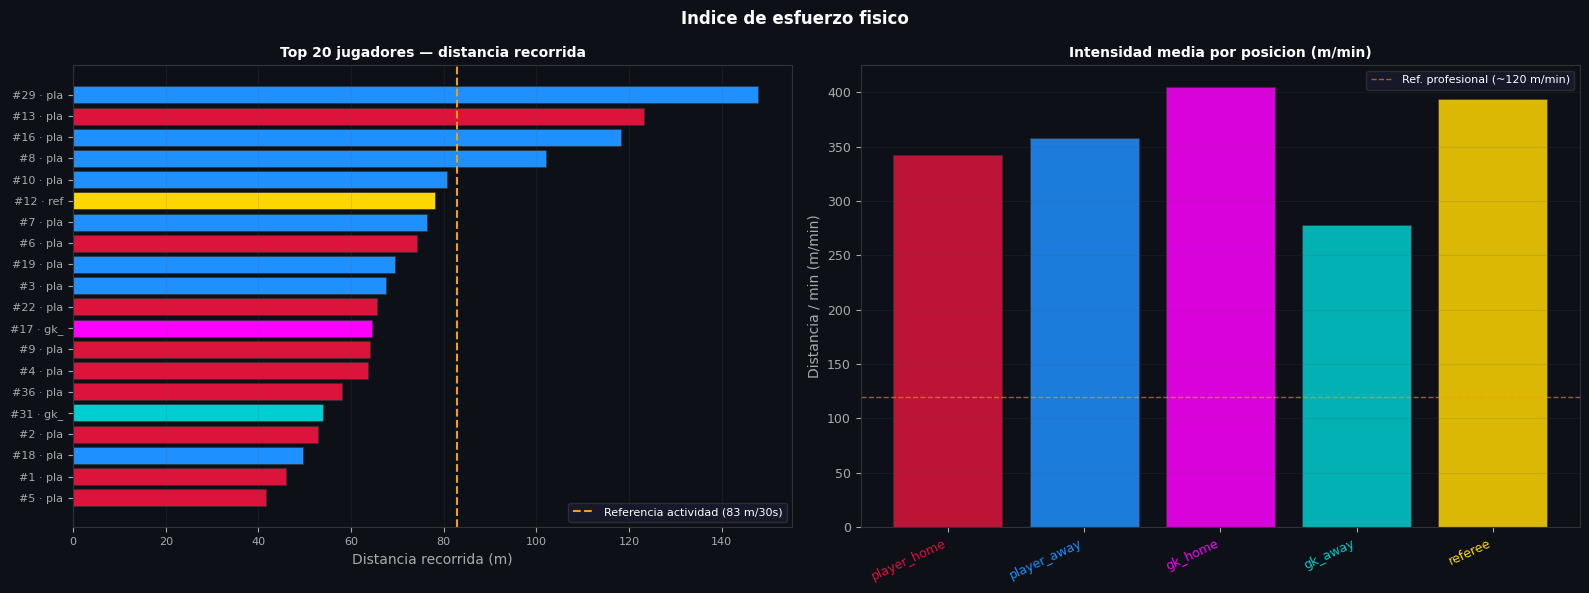

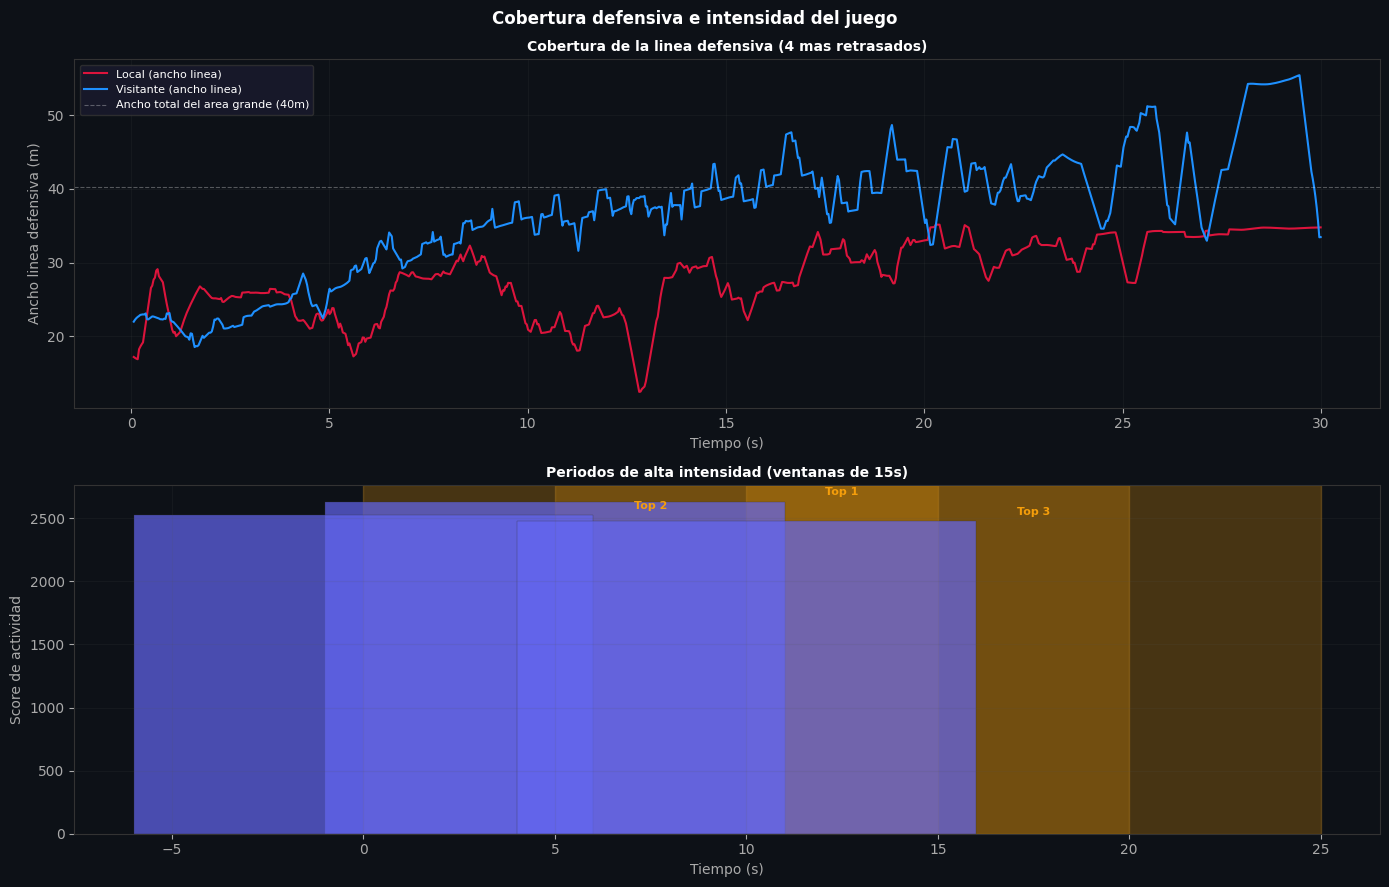

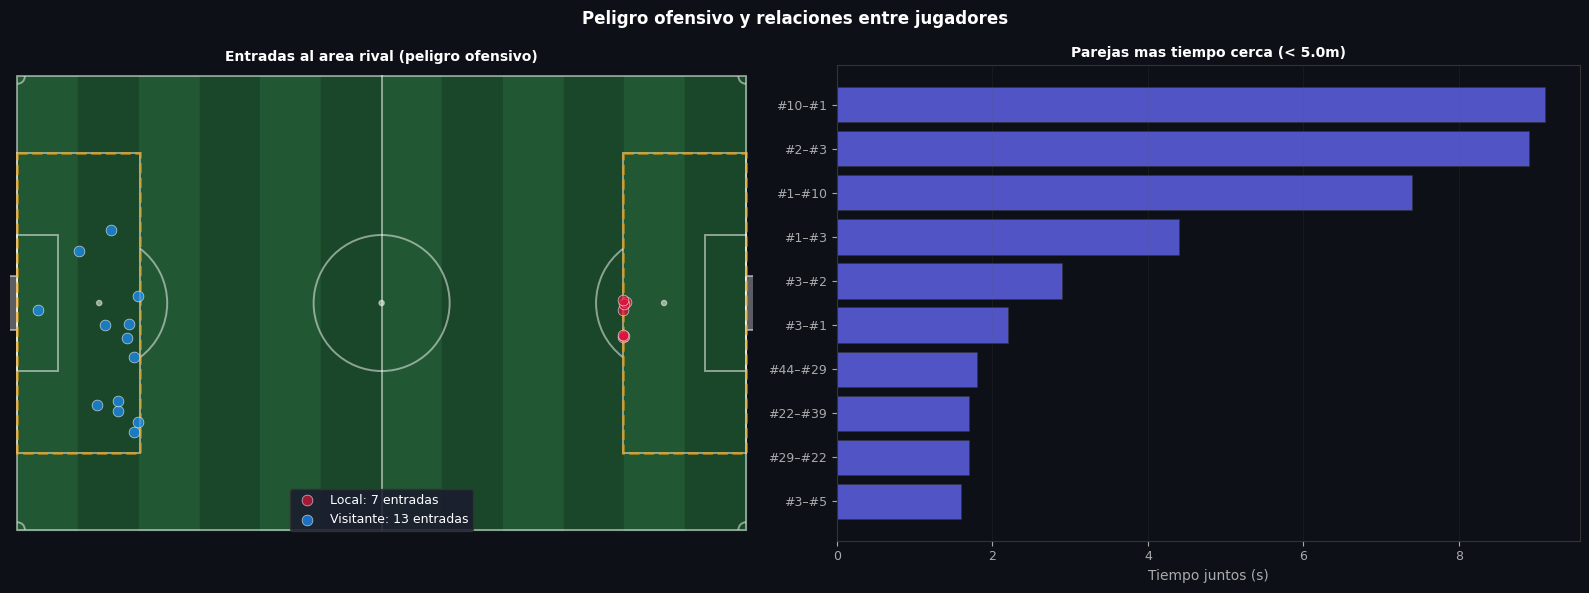


══════════════════════════════════════════════════════════
  RESUMEN DE ESFUERZO FISICO
  ────────────────────────────────────────────────────
  Clase          Dist.media  Dist.max   m/min
  ────────────────────────────────────────────────────
  player_home          43m      123m     342
  player_away          54m      148m     358
  gk_home              32m       65m     404
  gk_away              54m       54m     278
  referee              27m       78m     394

  Referencia (30s activos): ~83m

  Entradas al area rival
  Local    : 7
  Visitante: 13

  Top 3 periodos de mayor intensidad:
    1. t=5s–20s  (score=2629.2)
    2. t=0s–15s  (score=2525.4)
    3. t=10s–25s  (score=2477.4)
══════════════════════════════════════════════════════════


In [23]:
# ═══════════════════════════════════════════════════════════
#  ESTADISTICAS AVANZADAS — FUTBOL MODESTO
#
#  1. Indice de esfuerzo por jugador (distancia/min por posicion)
#  2. Cobertura defensiva (anchura de la linea defensiva en el tiempo)
#  3. Periodos de alta intensidad (ventanas de 30s con mas accion)
#  4. Proximidad entre jugadores (parejas que mas tiempo juntas)
#  5. Zona de peligro: entradas al area rival por equipo
# ═══════════════════════════════════════════════════════════
from scipy.spatial.distance import cdist as _cdist
import warnings; warnings.filterwarnings('ignore')

# ── Constantes locales (no vienen del notebook de tracking) ──
# Umbral para filtrar saltos de homografia (teletransportaciones)
_MAX_JUMP_M = 9.0    # si un jugador se mueve >9m entre frames, ignorar
# Tiempo total analizado
_t_seg = float(df['time_s'].max() - df['time_s'].min()) if len(df) else 30.0

# ── Asegurar columna speed_kmh ────────────────────────────
if 'speed_kmh' not in df_known.columns:
    if 'speed_ms' in df_known.columns:
        df_known['speed_kmh'] = df_known['speed_ms'] * MS_TO_KMH
    else:
        df_known['speed_kmh'] = 0.0

# ── 1. INDICE DE ESFUERZO ─────────────────────────────────
# Distancia total recorrida por jugador (filtrada de saltos)
def _player_distance(df_g):
    rows = []
    t_min = df_g['time_s'].max() / 60.0 if 'time_s' in df_g.columns else 1.0
    for gid, grp in df_g.groupby('gid'):
        grp = grp.sort_values('frame')
        cls = grp['cls'].mode()[0]
        dx  = grp['x_m'].diff().fillna(0)
        dy  = grp['y_m'].diff().fillna(0)
        d   = np.sqrt(dx**2 + dy**2)
        d[d > _MAX_JUMP_M] = 0   # filtrar teletransportaciones / gaps de homografia
        dist = d.sum()
        rows.append({
            'gid':        gid,
            'cls':        cls,
            'dist_m':     round(dist, 1),
            'dist_km':    round(dist / 1000, 3),
            'n_frames':   len(grp),
            'time_min':   round(len(grp) / FPS / 60, 2),
            'dist_min':   round(dist / max(len(grp)/FPS/60, 0.01), 1),
            'max_kmh':    round(grp['speed_kmh'].max(), 1) if 'speed_kmh' in grp else 0,
            'team':       'home' if cls in TEAM_HOME else 'away' if cls in TEAM_AWAY else 'ref',
        })
    return pd.DataFrame(rows).sort_values('dist_m', ascending=False)

df_effort = _player_distance(df_known)

# Referenciar con benchmark reales (futbol profesional ~10-12 km/partido)
# En 30s de muestreo, proporcional: ~83m/30s = un jugador activo normal
BENCH_MS  = 83.0   # metros esperados en 30s de juego activo
t_seg     = _t_seg                       # segundos totales del segmento analizado
bench_seg = BENCH_MS * (t_seg / 30.0)   # referencia proporcional al tiempo

# ── 2. COBERTURA DEFENSIVA ────────────────────────────────
# Ancho de la linea defensiva = rango Y de los 4 mas retrasados
def _defensive_coverage(df_k, cls_list, attack_right=True, n_def=4):
    rows = []
    for frame, grp in df_k[df_k['cls'].isin(cls_list)].groupby('frame'):
        pts = grp.sort_values('x_m' if attack_right else 'x_m',
                               ascending=attack_right)
        defenders = pts.head(n_def)
        if len(defenders) < 2:
            continue
        width = defenders['y_m'].max() - defenders['y_m'].min()
        depth = defenders['x_m'].std()
        rows.append({
            'frame':  frame,
            'time_s': grp['time_s'].iloc[0],
            'width':  round(width, 2),
            'depth_std': round(depth, 2),
        })
    return pd.DataFrame(rows)

_cx_h = df_known[df_known['cls'].isin(TEAM_HOME)]['x_m'].mean()
_cx_a = df_known[df_known['cls'].isin(TEAM_AWAY)]['x_m'].mean()
_home_right = _cx_h > _cx_a

cov_home = _defensive_coverage(df_known, TEAM_HOME, attack_right=_home_right)
cov_away = _defensive_coverage(df_known, TEAM_AWAY, attack_right=(not _home_right))

# ── 3. PERIODOS DE ALTA INTENSIDAD ───────────────────────
# Ventanas de 30s (900 frames) con mayor densidad de accion
WINDOW_S   = 15.0   # ventana en segundos
WINDOW_F   = int(WINDOW_S * FPS)
STEP_F     = int(5 * FPS)    # cada 5s

def _activity_score(df_g, start_f, end_f):
    """
    Score de actividad en una ventana de frames:
      - Numero de detecciones
      - Velocidad media
      - Jugadores en tercios extremos
    """
    sub = df_g[(df_g['frame'] >= start_f) & (df_g['frame'] < end_f)]
    if len(sub) == 0:
        return 0.0
    n_dets  = len(sub)
    v_mean  = sub['speed_kmh'].mean() if 'speed_kmh' in sub else 0.0
    extreme = ((sub['x_m'] < L_M * 0.2) | (sub['x_m'] > L_M * 0.8)).sum()
    return round(n_dets * 0.3 + v_mean * 0.5 + extreme * 0.2, 2)

# Inicializacion por si el segmento es demasiado corto para las ventanas
df_windows  = pd.DataFrame()
top_periods = pd.DataFrame()

frames_sorted = sorted(df_known['frame'].unique())
if len(frames_sorted) > WINDOW_F:
    f_min, f_max = frames_sorted[0], frames_sorted[-1]
    windows = []
    for f_start in range(f_min, f_max - WINDOW_F, STEP_F):
        score = _activity_score(df_known, f_start, f_start + WINDOW_F)
        t_s = (f_start - f_min) / FPS
        windows.append({'f_start': f_start, 'time_s': round(t_s, 1),
                        'score': score})
    df_windows = pd.DataFrame(windows).sort_values('score', ascending=False)
    top_periods = df_windows.head(5).reset_index(drop=True)
else:
    df_windows = pd.DataFrame()
    top_periods = pd.DataFrame()

# ── 4. PROXIMIDAD ENTRE JUGADORES ────────────────────────
# Top 10 parejas que mas tiempo pasan cerca (< 5m)
PROX_DIST  = 5.0
def _player_proximity(df_g, prox_m=PROX_DIST):
    counts = {}
    for frame, grp in df_g.groupby('frame'):
        players = grp[['gid', 'x_m', 'y_m', 'cls']].values
        for i in range(len(players)):
            for j in range(i+1, len(players)):
                d = np.sqrt((players[i,1]-players[j,1])**2 +
                            (players[i,2]-players[j,2])**2)
                if d < prox_m:
                    key = (int(players[i,0]), int(players[j,0]))
                    counts[key] = counts.get(key, 0) + 1
    rows = [{'gid_a': k[0], 'gid_b': k[1],
             'frames_close': v, 'time_s': round(v/FPS, 1)}
            for k, v in counts.items()]
    return pd.DataFrame(rows).sort_values('frames_close', ascending=False) \
           if rows else pd.DataFrame()

df_prox = _player_proximity(df_known)

# ── 5. ENTRADAS AL AREA RIVAL ────────────────────────────
AREA_W  = 40.32 / 2   # semi-anchura del area grande
def _box_entries(df_g, cls_list, attack_right=True):
    """Detecta cada vez que un jugador entra al area rival."""
    entries = []
    for gid, grp in df_g[df_g['cls'].isin(cls_list)].groupby('gid'):
        grp = grp.sort_values('frame')
        in_box = False
        for _, row in grp.iterrows():
            xm, ym = row['x_m'], row['y_m']
            if attack_right:
                inside = xm > L_M - 16.5 and abs(ym - A_M/2) < AREA_W
            else:
                inside = xm < 16.5 and abs(ym - A_M/2) < AREA_W
            if inside and not in_box:
                entries.append({'gid': gid, 'cls': row['cls'],
                                'frame': row['frame'], 'time_s': row['time_s'],
                                'x_m': xm, 'y_m': ym})
                in_box = True
            elif not inside:
                in_box = False
    return pd.DataFrame(entries)

entries_home = _box_entries(df_known, TEAM_HOME, attack_right=_home_right)
entries_away = _box_entries(df_known, TEAM_AWAY, attack_right=(not _home_right))


# ════════════════════════════════════════════════════════
# FIGURA 1: Esfuerzo por jugador
# ════════════════════════════════════════════════════════
fig1, axes = plt.subplots(1, 2, figsize=(16, 6))
fig1.patch.set_facecolor(DARK_BG)

# Panel A: distancia total por jugador (top 20)
ax_d = axes[0]
ax_d.set_facecolor(DARK_BG)
for sp in ax_d.spines.values(): sp.set_color('#333')

top20 = df_effort.head(20)
bar_c = [COLOR_MAP.get(r.cls, '#aaa') for r in top20.itertuples()]
ax_d.barh([f"#{int(r.gid)} · {r.cls[:3]}" for r in top20.itertuples()],
          top20['dist_m'], color=bar_c, edgecolor='#333', lw=0.5)
ax_d.axvline(bench_seg, color='#f59e0b', lw=1.5, ls='--',
             label=f'Referencia actividad ({bench_seg:.0f} m/{t_seg:.0f}s)')
ax_d.invert_yaxis()
ax_d.set_xlabel('Distancia recorrida (m)', color='#aaa')
ax_d.tick_params(colors='#aaa', labelsize=8)
ax_d.grid(axis='x', alpha=0.15, color='#555')
ax_d.legend(fontsize=8, facecolor='#1a1a2e', labelcolor='white',
            edgecolor='#333', framealpha=0.8)
ax_d.set_title('Top 20 jugadores — distancia recorrida', color='white',
               fontsize=10, fontweight='bold')

# Panel B: distancia/min por clase (intensidad normalizada)
ax_i = axes[1]
ax_i.set_facecolor(DARK_BG)
for sp in ax_i.spines.values(): sp.set_color('#333')

dm_cls = df_effort.groupby('cls')['dist_min'].mean().reindex(CLASSES_ORDER).dropna()
ax_i.bar(dm_cls.index, dm_cls.values,
         color=[COLOR_MAP.get(c,'#aaa') for c in dm_cls.index],
         edgecolor='#333', lw=0.5, alpha=0.85)
ax_i.set_ylabel('Distancia / min (m/min)', color='#aaa')
ax_i.tick_params(colors='#aaa', labelsize=9)
ax_i.set_xticklabels(dm_cls.index, rotation=25, ha='right')
ax_i.grid(axis='y', alpha=0.15, color='#555')
ax_i.set_title('Intensidad media por posicion (m/min)', color='white',
               fontsize=10, fontweight='bold')
# Referencia: ~120 m/min = jugador profesional activo
ax_i.axhline(120, color='#f59e0b', lw=1, ls='--', alpha=0.6,
             label='Ref. profesional (~120 m/min)')
ax_i.legend(fontsize=8, facecolor='#1a1a2e', labelcolor='white',
            edgecolor='#333', framealpha=0.8)
for tick, c in zip(ax_i.get_xticklabels(), dm_cls.index):
    tick.set_color(COLOR_MAP.get(c, 'white'))

fig1.suptitle('Indice de esfuerzo fisico', color='white',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════
# FIGURA 2: Cobertura defensiva + periodos de intensidad
# ════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
fig2.patch.set_facecolor(DARK_BG)

# Panel A: cobertura defensiva en el tiempo
ax_cov = axes2[0]
ax_cov.set_facecolor(DARK_BG)
for sp in ax_cov.spines.values(): sp.set_color('#333')

if len(cov_home):
    roll_h = cov_home['width'].rolling(15, min_periods=1, center=True).mean()
    ax_cov.plot(cov_home['time_s'], roll_h,
                color=COLOR_MAP['player_home'], lw=1.5, label='Local (ancho linea)')
if len(cov_away):
    roll_a = cov_away['width'].rolling(15, min_periods=1, center=True).mean()
    ax_cov.plot(cov_away['time_s'], roll_a,
                color=COLOR_MAP['player_away'], lw=1.5, label='Visitante (ancho linea)')

ax_cov.axhline(40.32, color='white', lw=0.8, ls='--', alpha=0.3,
               label='Ancho total del area grande (40m)')
ax_cov.set_ylabel('Ancho linea defensiva (m)', color='#aaa')
ax_cov.set_xlabel('Tiempo (s)', color='#aaa')
ax_cov.tick_params(colors='#aaa')
ax_cov.grid(alpha=0.12, color='#555')
ax_cov.legend(fontsize=8, facecolor='#1a1a2e', labelcolor='white',
              edgecolor='#333', framealpha=0.8)
ax_cov.set_title('Cobertura de la linea defensiva (4 mas retrasados)',
                 color='white', fontsize=10, fontweight='bold')

# Panel B: score de actividad por ventana de 15s
ax_act = axes2[1]
ax_act.set_facecolor(DARK_BG)
for sp in ax_act.spines.values(): sp.set_color('#333')

if len(df_windows):
    ax_act.bar(df_windows['time_s'], df_windows['score'],
               width=WINDOW_S * 0.8, color='#6366f1', alpha=0.7,
               edgecolor='#333', lw=0.3)
    # Marcar top 3 periodos
    if len(top_periods) >= 3:
        for i, row in top_periods.head(3).iterrows():
            ax_act.axvspan(row['time_s'], row['time_s'] + WINDOW_S,
                           alpha=0.25, color='#f59e0b', zorder=0)
            ax_act.text(row['time_s'] + WINDOW_S/2, row['score'] * 1.02,
                        f"Top {i+1}", color='#f59e0b', fontsize=8,
                        ha='center', fontweight='bold')

ax_act.set_xlabel('Tiempo (s)', color='#aaa')
ax_act.set_ylabel('Score de actividad', color='#aaa')
ax_act.tick_params(colors='#aaa')
ax_act.grid(alpha=0.12, color='#555')
ax_act.set_title(f'Periodos de alta intensidad (ventanas de {WINDOW_S:.0f}s)',
                 color='white', fontsize=10, fontweight='bold')

fig2.suptitle('Cobertura defensiva e intensidad del juego',
              color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════════════
# FIGURA 3: Entradas al area + proximidad de jugadores
# ════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))
fig3.patch.set_facecolor(DARK_BG)

# Panel A: mapa de entradas al area
ax_ent = axes3[0]
draw_pitch(ax_ent, alpha_lines=0.5)

for entries, col, lbl in [
    (entries_home, COLOR_MAP['player_home'], 'Local'),
    (entries_away, COLOR_MAP['player_away'], 'Visitante'),
]:
    if len(entries):
        ax_ent.scatter(entries['x_m'], entries['y_m'],
                       color=col, s=60, alpha=0.7, zorder=5,
                       edgecolors='white', lw=0.5,
                       label=f'{lbl}: {len(entries)} entradas')

# Dibujar areas
for xg, w in [(0, 16.5), (L_M - 16.5, 16.5)]:
    ax_ent.add_patch(plt.Rectangle((xg, A_M/2 - AREA_W), w, 2*AREA_W,
                                    fill=False, edgecolor='#f59e0b',
                                    lw=2, ls='--', zorder=4, alpha=0.6))

ax_ent.legend(fontsize=9, facecolor='#1a1a2e', labelcolor='white',
              edgecolor='#333', framealpha=0.85)
ax_ent.set_title('Entradas al area rival (peligro ofensivo)',
                 color='white', fontsize=10, fontweight='bold')

# Panel B: top 10 parejas de jugadores que mas tiempo juntos
ax_prx = axes3[1]
ax_prx.set_facecolor(DARK_BG)
for sp in ax_prx.spines.values(): sp.set_color('#333')

if len(df_prox) >= 2:
    top_prox = df_prox.head(10)
    ax_prx.barh(
        [f"#{int(r.gid_a)}–#{int(r.gid_b)}" for r in top_prox.itertuples()],
        top_prox['time_s'],
        color='#6366f1', edgecolor='#333', lw=0.5, alpha=0.8
    )
    ax_prx.invert_yaxis()
    ax_prx.set_xlabel('Tiempo juntos (s)', color='#aaa')
    ax_prx.tick_params(colors='#aaa', labelsize=9)
    ax_prx.grid(axis='x', alpha=0.15, color='#555')
ax_prx.set_title(f'Parejas mas tiempo cerca (< {PROX_DIST}m)',
                 color='white', fontsize=10, fontweight='bold')

fig3.suptitle('Peligro ofensivo y relaciones entre jugadores',
              color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


# ── Resumen textual ───────────────────────────────────────
print(f"\n{'═'*58}")
print(f"  RESUMEN DE ESFUERZO FISICO")
print(f"  {'─'*52}")
print(f"  {'Clase':<14} {'Dist.media':>10} {'Dist.max':>9} {'m/min':>7}")
print(f"  {'─'*52}")
for cls_n in CLASSES_ORDER:
    sub = df_effort[df_effort['cls'] == cls_n]
    if not len(sub): continue
    print(f"  {cls_n:<14} {sub['dist_m'].mean():>8.0f}m  "
          f"{sub['dist_m'].max():>7.0f}m  {sub['dist_min'].mean():>6.0f}")

print(f"\n  Referencia (30s activos): ~{bench_seg:.0f}m")
print(f"\n  Entradas al area rival")
print(f"  Local    : {len(entries_home)}")
print(f"  Visitante: {len(entries_away)}")

if len(top_periods):
    print(f"\n  Top 3 periodos de mayor intensidad:")
    for i, row in top_periods.head(3).iterrows():
        print(f"    {i+1}. t={row['time_s']:.0f}s–{row['time_s']+WINDOW_S:.0f}s  "
              f"(score={row['score']:.1f})")
print(f"{'═'*58}")


## 11 · Dashboard resumen
Figura de 12 paneles con todas las métricas clave. Se guarda como `dashboard_tactico.png` para incluir en la memoria del TFG.

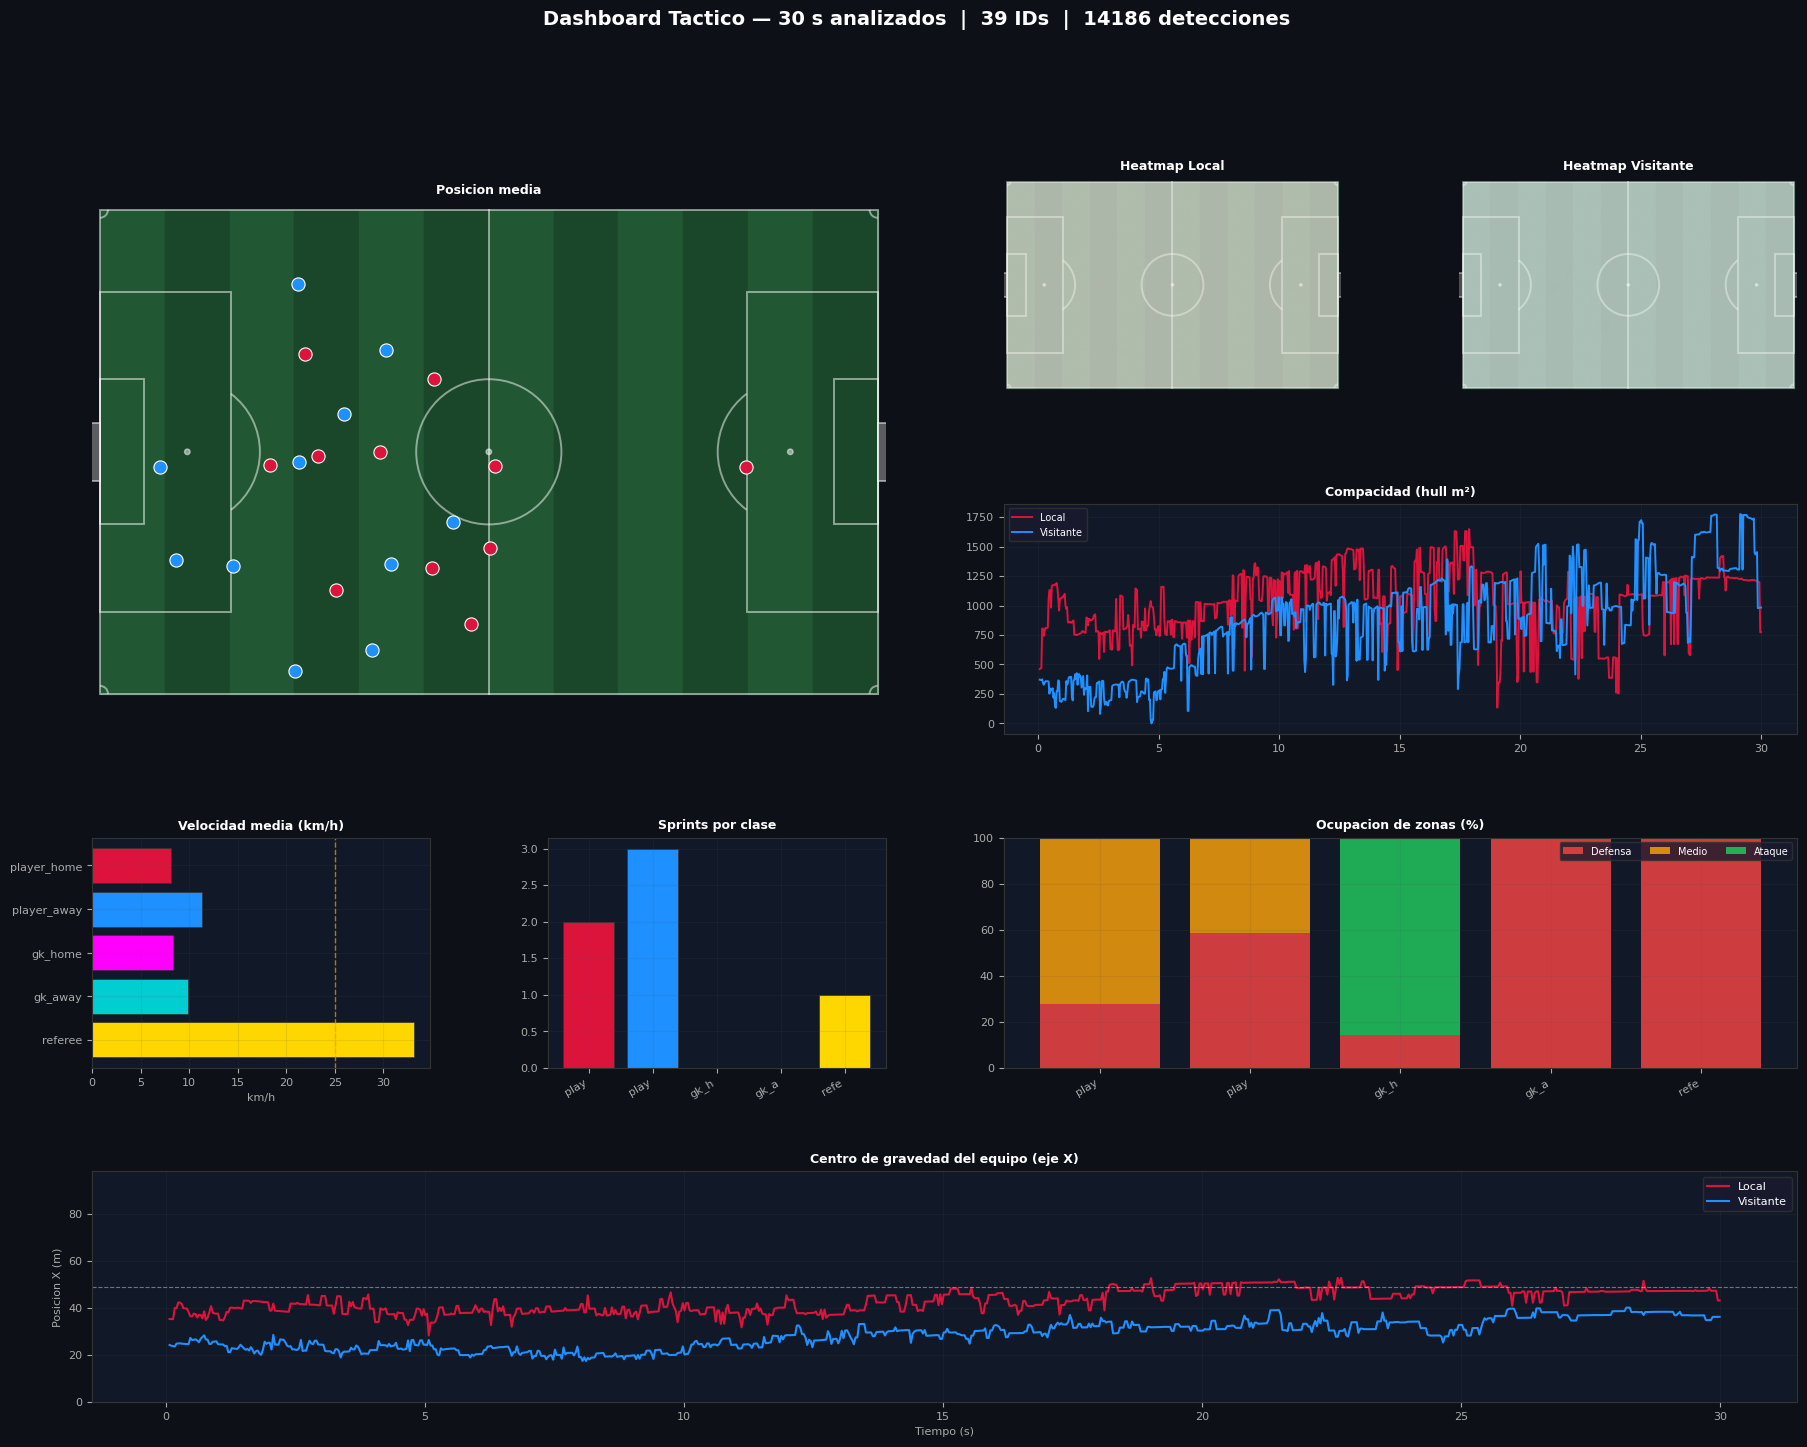

Dashboard guardado: dashboard_tactico.png


In [24]:
# ═══════════════════════════════════════════════════════════
#  DASHBOARD RESUMEN DE PARTIDO
#  1 figura con todas las metricas clave en 12 paneles
# ═══════════════════════════════════════════════════════════

fig = plt.figure(figsize=(22, 16))
fig.patch.set_facecolor(DARK_BG)
gs  = gridspec.GridSpec(4, 4, figure=fig, hspace=0.45, wspace=0.35)

# ── Helper para estilo de eje ─────────────────────────────
def _style(ax, title=''):
    ax.set_facecolor('#111827')
    ax.tick_params(colors='#aaa', labelsize=8)
    ax.grid(alpha=0.12, color='#555')
    for sp in ax.spines.values(): sp.set_color('#333')
    if title:
        ax.set_title(title, color='white', fontsize=9, fontweight='bold')

# ─────────────────────────────────────────────────────────
# [0,0-1]  Campo con posiciones medias (formacion)
ax_form = fig.add_subplot(gs[:2, :2])
draw_pitch(ax_form, alpha_lines=0.5)
for _, row in avg_home.iterrows():
    ax_form.scatter(row['mean_x'], row['mean_y'],
                    color=COLOR_MAP['player_home'], s=90, zorder=5,
                    edgecolors='white', lw=0.8)
for _, row in avg_away.iterrows():
    ax_form.scatter(row['mean_x'], row['mean_y'],
                    color=COLOR_MAP['player_away'], s=90, zorder=5,
                    edgecolors='white', lw=0.8)
ax_form.set_title('Posicion media', color='white', fontsize=9, fontweight='bold')

# ─────────────────────────────────────────────────────────
# [0,2]  Heatmap local
ax_hm_h = fig.add_subplot(gs[0, 2])
draw_pitch(ax_hm_h, alpha_lines=0.4)
hm_h = np.zeros((int(A_M*10), int(L_M*10)), dtype=np.float32)
for _, row in df_known[df_known['cls'].isin(TEAM_HOME)].iterrows():
    px = int(np.clip(row['x_m']*10, 0, int(L_M*10)-1))
    py = int(np.clip(row['y_m']*10, 0, int(A_M*10)-1))
    hm_h[py, px] += 1.0
if hm_h.max() > 0: hm_h /= hm_h.max()
hm_h = gaussian_filter(hm_h, 8)
ax_hm_h.imshow(hm_h, extent=[0, L_M, A_M, 0], origin='upper',
               cmap='Reds', alpha=0.65, vmin=0, vmax=1, zorder=4)
_style(ax_hm_h, 'Heatmap Local')

# ─────────────────────────────────────────────────────────
# [0,3]  Heatmap visitante
ax_hm_a = fig.add_subplot(gs[0, 3])
draw_pitch(ax_hm_a, alpha_lines=0.4)
hm_a = np.zeros((int(A_M*10), int(L_M*10)), dtype=np.float32)
for _, row in df_known[df_known['cls'].isin(TEAM_AWAY)].iterrows():
    px = int(np.clip(row['x_m']*10, 0, int(L_M*10)-1))
    py = int(np.clip(row['y_m']*10, 0, int(A_M*10)-1))
    hm_a[py, px] += 1.0
if hm_a.max() > 0: hm_a /= hm_a.max()
hm_a = gaussian_filter(hm_a, 8)
ax_hm_a.imshow(hm_a, extent=[0, L_M, A_M, 0], origin='upper',
               cmap='Blues', alpha=0.65, vmin=0, vmax=1, zorder=4)
_style(ax_hm_a, 'Heatmap Visitante')

# ─────────────────────────────────────────────────────────
# [1,2-3]  Compacidad en el tiempo
ax_compact = fig.add_subplot(gs[1, 2:])
if len(home_metrics) and len(away_metrics):
    ax_compact.plot(home_metrics['time_s'], home_metrics['hull_area'],
                    color=COLOR_MAP['player_home'], lw=1.4, label='Local')
    ax_compact.plot(away_metrics['time_s'], away_metrics['hull_area'],
                    color=COLOR_MAP['player_away'], lw=1.4, label='Visitante')
    ax_compact.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='white',
                      edgecolor='#333', framealpha=0.8)
_style(ax_compact, 'Compacidad (hull m²)')

# ─────────────────────────────────────────────────────────
# [2,0]  Velocidad media por clase
ax_vel = fig.add_subplot(gs[2, 0])
if 'speed_kmh' in df_known.columns or 'speed_ms' in df_known.columns:
    _spd_col = 'speed_kmh' if 'speed_kmh' in df_known.columns else 'speed_ms'
    _factor  = 1.0 if _spd_col == 'speed_kmh' else MS_TO_KMH
    vel_by_cls = (df_known.groupby('cls')[_spd_col].mean() * _factor
                  ).reindex(CLASSES_ORDER).dropna()
    bar_colors = [COLOR_MAP.get(c, '#aaa') for c in vel_by_cls.index]
    ax_vel.barh(vel_by_cls.index, vel_by_cls.values,
                color=bar_colors, edgecolor='#333', lw=0.5)
    ax_vel.axvline(SPRINT_KMH, color='#f59e0b', lw=1, ls='--', alpha=0.7)
    ax_vel.invert_yaxis()
    ax_vel.set_xlabel('km/h', color='#aaa', fontsize=8)
    for tick in ax_vel.get_yticklabels():
        cls_n = tick.get_text()
        tick.set_color(COLOR_MAP.get(cls_n, 'white'))
_style(ax_vel, 'Velocidad media (km/h)')

# ─────────────────────────────────────────────────────────
# [2,1]  Sprints por equipo
ax_sp = fig.add_subplot(gs[2, 1])
if len(df_sprints):
    sp_cls = df_sprints.groupby('cls').size().reindex(CLASSES_ORDER).fillna(0)
    ax_sp.bar(sp_cls.index, sp_cls.values,
              color=[COLOR_MAP.get(c,'#aaa') for c in sp_cls.index],
              edgecolor='#333', lw=0.5)
    ax_sp.set_xticklabels([c[:4] for c in sp_cls.index], rotation=30,
                           ha='right', fontsize=7, color='#aaa')
_style(ax_sp, 'Sprints por clase')

# ─────────────────────────────────────────────────────────
# [2,2-3]  Distribucion de zonas
ax_zone = fig.add_subplot(gs[2, 2:])
if len(df_known):
    def _zone(x):
        return 'Defensa' if x < L_M/3 else ('Medio' if x < 2*L_M/3 else 'Ataque')
    df_known['zone_d'] = df_known['x_m'].apply(_zone)
    zone_pct = df_known.groupby(['cls','zone_d']).size().unstack(fill_value=0)
    zone_pct = zone_pct.div(zone_pct.sum(axis=1), axis=0) * 100
    zones    = ['Defensa', 'Medio', 'Ataque']
    zcolors  = ['#ef4444', '#f59e0b', '#22c55e']
    bottom   = np.zeros(len(CLASSES_ORDER))
    for zone, zcol in zip(zones, zcolors):
        vals = [zone_pct.loc[c, zone] if c in zone_pct.index and zone in zone_pct.columns
                else 0 for c in CLASSES_ORDER]
        ax_zone.bar(CLASSES_ORDER, vals, bottom=bottom, color=zcol,
                    label=zone, alpha=0.85)
        bottom += np.array(vals)
    ax_zone.set_ylim(0, 100)
    ax_zone.set_xticklabels([c[:4] for c in CLASSES_ORDER], rotation=30,
                             ha='right', fontsize=7, color='#aaa')
    ax_zone.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='white',
                   edgecolor='#333', framealpha=0.8, ncol=3)
_style(ax_zone, 'Ocupacion de zonas (%)')

# ─────────────────────────────────────────────────────────
# [3,:]  Centroide X en el tiempo (ambos equipos)
ax_centroid = fig.add_subplot(gs[3, :])
if len(home_metrics) and len(away_metrics):
    ax_centroid.plot(home_metrics['time_s'], home_metrics['centroid_x'],
                     color=COLOR_MAP['player_home'], lw=1.5, label='Local')
    ax_centroid.plot(away_metrics['time_s'], away_metrics['centroid_x'],
                     color=COLOR_MAP['player_away'], lw=1.5, label='Visitante')
    ax_centroid.axhline(L_M/2, color='white', lw=0.8, ls='--', alpha=0.4)
    ax_centroid.set_ylim(0, L_M)
    ax_centroid.set_xlabel('Tiempo (s)', color='#aaa', fontsize=8)
    ax_centroid.set_ylabel('Posicion X (m)', color='#aaa', fontsize=8)
    ax_centroid.legend(fontsize=8, facecolor='#1a1a2e', labelcolor='white',
                       edgecolor='#333', framealpha=0.8)
_style(ax_centroid, 'Centro de gravedad del equipo (eje X)')

# ─────────────────────────────────────────────────────────
t_s = df['time_s'].max() - df['time_s'].min() if len(df) else 0
fig.suptitle(
    f"Dashboard Tactico — {t_s:.0f} s analizados  |  "
    f"{df['gid'].nunique()} IDs  |  {len(df)} detecciones",
    color='white', fontsize=14, fontweight='bold'
)
plt.savefig('dashboard_tactico.png', dpi=150, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print("Dashboard guardado: dashboard_tactico.png")
